# NCAAM 2020–2026 Training Dataset – Exploratory Data Analysis

This notebook loads `ncaam_20_26_training_dataset.csv` from your home directory and performs basic exploratory data analysis (EDA).

- **Source CSV**: `~/ncaam_20_26_training_dataset.csv`
- **Goals**:
  - Inspect shape, schema, and basic statistics
  - Check for missing values
  - Visualize distributions
  - Examine correlations between numeric features

Run the cells top-to-bottom after opening this notebook in your environment.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
plt.style.use("seaborn-v0_8")
sns.set_theme()

# Path to the CSV (expand "~" so this works on your machine)
data_path = os.path.expanduser("~/ncaam_20_26_training_dataset.csv")

# Load data
df = pd.read_csv(data_path)

print("Loaded shape:", df.shape)
df.head()


Loaded shape: (3317765, 30)


,match_id,action_number,clock,shot_clock,time_actual,period,period_type,team_id,action_type,success,...,score1,score2,players_team1,players_team2,created_at,updated_at,deleted_at,public_id,team_name,opponent_name
0,1781091,3,19:31:00,NaN,2022-11-02 10:27:54.000 -0400,1,REGULAR,103551,3pt,False,...,0,0,{},{},2024-05-22 13:27:09.132 -0400,2024-05-22 13:27:09.132 -0400,NaN,fb76e452-4800-4b99-82b1-cc0d16b6a318,ETSU,Abilene Christian
1,1781091,8,18:52:00,NaN,2022-11-02 10:27:54.000 -0400,1,REGULAR,103551,freethrow,True,...,1,2,{},{},2024-05-22 13:27:09.132 -0400,2024-05-22 13:27:09.132 -0400,NaN,f52b396e-8656-436d-88e4-8b4d30b72a4e,ETSU,Abilene Christian
2,1781091,9,18:52:00,NaN,2022-11-02 10:27:54.000 -0400,1,REGULAR,103551,freethrow,False,...,1,2,{},{},2024-05-22 13:27:09.132 -0400,2024-05-22 13:27:09.132 -0400,NaN,a44c7540-06d5-46fd-aa6e-5d9dfca0a700,ETSU,Abilene Christian
3,1781091,19,17:52:00,NaN,2022-11-02 10:27:54.000 -0400,1,REGULAR,103551,3pt,False,...,1,5,{},{},2024-05-22 13:27:09.132 -0400,2024-05-22 13:27:09.132 -0400,NaN,9d98c094-3841-448c-8f40-d0653f5f3d48,ETSU,Abilene Christian
4,1781091,27,17:37:00,NaN,2022-11-02 10:27:54.000 -0400,1,REGULAR,103551,3pt,True,...,4,5,{},{},2024-05-22 13:27:09.132 -0400,2024-05-22 13:27:09.132 -0400,NaN,15e19e39-72ff-4291-991f-af1fae169781,ETSU,Abilene Christian


## Feature Engineering

### Derive shot_distance

Using the NCAAM court dimensions (94 ft by 50 ft), we convert the percentage-based `x`/`y` coordinates into feet and compute the Euclidean distance to the shooting hoop, based on the `side` column (LEFT/RIGHT).


In [2]:
# Compute shot_distance column (in feet) for ncaam_20_26_training_dataset

COURT_LENGTH_FT = 94.0  # horizontal dimension
COURT_WIDTH_FT = 50.0   # vertical dimension

# Basket coordinates in feet
BASKET_LEFT = (5.25, 25.0)
BASKET_RIGHT = (88.75, 25.0)

# Convert percentage x/y to feet
x_ft = df["x"] / 100.0 * COURT_LENGTH_FT
y_ft = df["y"] / 100.0 * COURT_WIDTH_FT

shot_distance = np.full(len(df), np.nan, dtype=float)

# Only compute distances for 2pt/3pt shots (leave freethrows as NaN)
# and where both x and y are non-zero
mask_2pt_3pt = df["action_type"].isin(["2pt", "3pt"])
mask_nonzero_xy = (df["x"] != 0) & (df["y"] != 0)
valid_shots_mask = mask_2pt_3pt & mask_nonzero_xy

# LEFT side shots -> distance to left basket
mask_left = (df["side"] == "LEFT") & valid_shots_mask
shot_distance[mask_left] = np.sqrt(
    (x_ft[mask_left] - BASKET_LEFT[0]) ** 2 +
    (y_ft[mask_left] - BASKET_LEFT[1]) ** 2
)

# RIGHT side shots -> distance to right basket
mask_right = (df["side"] == "RIGHT") & valid_shots_mask
shot_distance[mask_right] = np.sqrt(
    (x_ft[mask_right] - BASKET_RIGHT[0]) ** 2 +
    (y_ft[mask_right] - BASKET_RIGHT[1]) ** 2
)

# Attach to main DataFrame
df["shot_distance"] = shot_distance

print("shot_distance summary (in feet):")
print(df["shot_distance"].describe())

# Show only rows where shot_distance is non-zero and not NaN
nonzero_sd_df = df[(df["shot_distance"] != 0) & df["shot_distance"].notna()]
nonzero_sd_df[["x", "y", "side", "shot_distance"]].head()


shot_distance summary (in feet):
count    2.462000e+06
mean     1.356686e+01
std      9.905915e+00
min      3.900000e-01
25%      3.782076e+00
50%      1.161112e+01
75%      2.400630e+01
max      8.908544e+01
Name: shot_distance, dtype: float64


,x,y,side,shot_distance
292,11.0,45.0,LEFT,5.670811
293,28.0,75.0,LEFT,24.498875
294,17.0,76.0,LEFT,16.856242
295,27.0,21.0,LEFT,24.808605
296,30.0,33.0,LEFT,24.473506


### Derive power conf vs non power conf boolean var

In [3]:
# Add team_advantage feature based on Power 5 conference membership

power_five_teams = [
    # ACC
    "Boston College", "Clemson", "Duke", "Florida St.", "Georgia Tech", "Louisville",
    "Miami (FL)", "NC State", "North Carolina", "Notre Dame", "Pittsburgh", "Syracuse",
    "Virginia", "Virginia Tech", "Wake Forest",
    # Big Ten
    "Illinois", "Indiana", "Iowa", "Maryland", "Michigan", "Michigan St.", "Minnesota",
    "Nebraska", "Northwestern", "Ohio St.", "Penn St.", "Purdue", "Rutgers", "Wisconsin",
    # Big 12 (incl. recent additions)
    "Arizona", "Arizona St.", "Baylor", "BYU", "Cincinnati", "Colorado", "Houston",
    "Iowa St.", "Kansas", "Kansas St.", "Oklahoma St.", "TCU", "Texas Tech", "UCF",
    "West Virginia",
    # SEC (incl. Texas & Oklahoma)
    "Alabama", "Arkansas", "Auburn", "Florida", "Georgia", "Kentucky", "LSU",
    "Mississippi St.", "Missouri", "Ole Miss", "South Carolina", "Tennessee", "Texas",
    "Texas A&M", "Vanderbilt", "Oklahoma",
    # Pac-12 legacy Power 5
    "California", "Oregon", "Oregon St.", "Southern California", "Stanford", "UCLA",
    "Utah", "Washington", "Washington St.",
]

team = df["team_name"]
opp = df["opponent_name"]

cond_team_in = team.isin(power_five_teams)
cond_opp_in = opp.isin(power_five_teams)

# Nullable boolean: True/False when asymmetry exists, <NA> otherwise
team_advantage = pd.Series(pd.NA, index=df.index, dtype="boolean")
team_advantage[cond_team_in & ~cond_opp_in] = True
team_advantage[~cond_team_in & cond_opp_in] = False

df["team_advantage"] = team_advantage

print("team_advantage value counts (including NaN):")
print(df["team_advantage"].value_counts(dropna=False))

print("\nRows where team_advantage is True (head):")
df[df["team_advantage"] == False].head()

team_advantage value counts (including NaN):
team_advantage
<NA>     2888008
True      223133
False     206624
Name: count, dtype: Int64

Rows where team_advantage is True (head):


,match_id,action_number,clock,shot_clock,time_actual,period,period_type,team_id,action_type,success,...,players_team1,players_team2,created_at,updated_at,deleted_at,public_id,team_name,opponent_name,shot_distance,team_advantage
363,1781893,19,19:17:00,00:00:00,2020-11-25 12:03:20.000 -0500,1,REGULAR,104122,3pt,False,...,"{1331987,950491,1331988,949493,995136}","{1594827,981121,934823,994176,1140074}",2024-05-27 10:56:16.550 -0400,2024-05-27 10:56:16.550 -0400,NaN,507465b5-1b00-4ea8-aa54-27a1b0f415ce,Radford,Virginia Tech,23.895232,False
364,1781893,25,19:15:00,00:00:00,2020-11-25 12:03:48.000 -0500,1,REGULAR,104122,freethrow,False,...,"{1331987,950491,1331988,949493,995136}","{1594827,981121,934823,994176,1140074}",2024-05-27 10:56:16.550 -0400,2024-05-27 10:56:16.550 -0400,NaN,47d76cc1-4c4b-4135-9c9f-31404924a645,Radford,Virginia Tech,NaN,False
365,1781893,27,19:15:00,00:00:00,2020-11-25 12:04:05.000 -0500,1,REGULAR,104122,freethrow,True,...,"{1331987,950491,1331988,949493,995136}","{1594827,981121,934823,994176,1140074}",2024-05-27 10:56:16.550 -0400,2024-05-27 10:56:16.550 -0400,NaN,a0005ae9-43c2-4f67-ac21-d62f7d63be84,Radford,Virginia Tech,NaN,False
366,1781893,32,18:38:00,00:00:00,2020-11-25 12:04:59.000 -0500,1,REGULAR,104122,2pt,True,...,"{1331987,950491,1331988,949493,995136}","{1594827,981121,934823,994176,1140074}",2024-05-27 10:56:16.550 -0400,2024-05-27 10:56:16.550 -0400,NaN,30b01ada-c2ea-4e68-9e5f-c57ae59bce04,Radford,Virginia Tech,4.171678,False
367,1781893,35,17:52:00,00:00:00,2020-11-25 12:05:36.000 -0500,1,REGULAR,104122,2pt,True,...,"{1331987,950491,1331988,949493,995136}","{1594827,981121,934823,994176,1140074}",2024-05-27 10:56:16.550 -0400,2024-05-27 10:56:16.550 -0400,NaN,44ca56c6-4b44-4041-a788-4850603cf9c3,Radford,Virginia Tech,19.556843,False


In [4]:
# Define feature and target columns for modeling
# Here we explicitly build a combined action/sub_type feature and use success as the target.

print("All columns:", list(df.columns))

ACTION_COL = "action_type"
SUBTYPE_COL = "sub_type"
TARGET_COL = "success"

missing_cols = [c for c in [ACTION_COL, SUBTYPE_COL, TARGET_COL] if c not in df.columns]
if missing_cols:
    raise KeyError(f"The following expected columns are missing from df: {missing_cols}")

# Build a combined feature representing the disjoint action_type/sub_type combinations
FEATURE_COMBO_COL = "action_type_sub_type_combo"
df[FEATURE_COMBO_COL] = df[ACTION_COL].astype(str) + " | " + df[SUBTYPE_COL].astype(str)

# Exclude certain action_type combinations entirely from analysis
EXCLUDED_ACTIONS = ["3pt", "layup"]
model_df = df[~df[ACTION_COL].isin(EXCLUDED_ACTIONS)][[FEATURE_COMBO_COL, TARGET_COL]].copy()

print(f"\nUsing combined feature column: {FEATURE_COMBO_COL} (from {ACTION_COL} + ' | ' + {SUBTYPE_COL})")
print(f"Using target column: {TARGET_COL}")
print(f"Excluded action_type values from analysis: {EXCLUDED_ACTIONS}")
print("Resulting model_df shape:", model_df.shape)

All columns: ['match_id', 'action_number', 'clock', 'shot_clock', 'time_actual', 'period', 'period_type', 'team_id', 'action_type', 'success', 'sub_type', 'qualifiers', 'value', 'previous_action', 'person_id', 'official_id', 'x', 'y', 'area', 'side', 'score1', 'score2', 'players_team1', 'players_team2', 'created_at', 'updated_at', 'deleted_at', 'public_id', 'team_name', 'opponent_name', 'shot_distance', 'team_advantage']

Using combined feature column: action_type_sub_type_combo (from action_type + ' | ' + sub_type)
Using target column: success
Excluded action_type values from analysis: ['3pt', 'layup']
Resulting model_df shape: (2361443, 2)


In [5]:
# Missing values summary (feature + target only)

missing_counts = model_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(model_df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
})

missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct


Target value counts (including NaN):
success
True     1357678
False    1003765
Name: count, dtype: int64


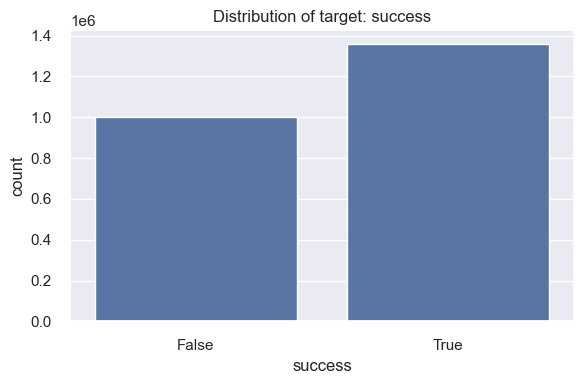

In [6]:
# Target distribution and basic stats

print("Target value counts (including NaN):")
print(model_df[TARGET_COL].value_counts(dropna=False))

plt.figure(figsize=(6, 4))
sns.countplot(data=model_df, x=TARGET_COL)
plt.title(f"Distribution of target: {TARGET_COL}")
plt.tight_layout()
plt.show()


In [7]:
# Success rate by action_type/sub_type combination

# Drop rows with missing target so rates are well-defined
rate_df = model_df.dropna(subset=[TARGET_COL])

rate_table = (
    rate_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"count": "n", "mean": "success_rate"})
)

# Filter out combinations with small sample sizes
MIN_N = 100
rate_table = (
    rate_table[rate_table["n"] >= MIN_N]
    .sort_values("success_rate", ascending=False)
)

print(f"Number of {FEATURE_COMBO_COL} combinations with n >= {MIN_N}: {len(rate_table)}")
rate_table.head(30)


Number of action_type_sub_type_combo combinations with n >= 100: 20


,n,success_rate
action_type_sub_type_combo,,
2pt | dunk,80371,0.878663
2pt | alleyoop,9920,0.877923
2pt | tipindunk,2035,0.855528
freethrow | 3of3,10484,0.816387
freethrow | 2of3,10488,0.805969
freethrow | 1of3,10488,0.754672
freethrow | 2of2,328887,0.747974
freethrow | 1of2,328938,0.736580
2pt | tipin,717,0.722455


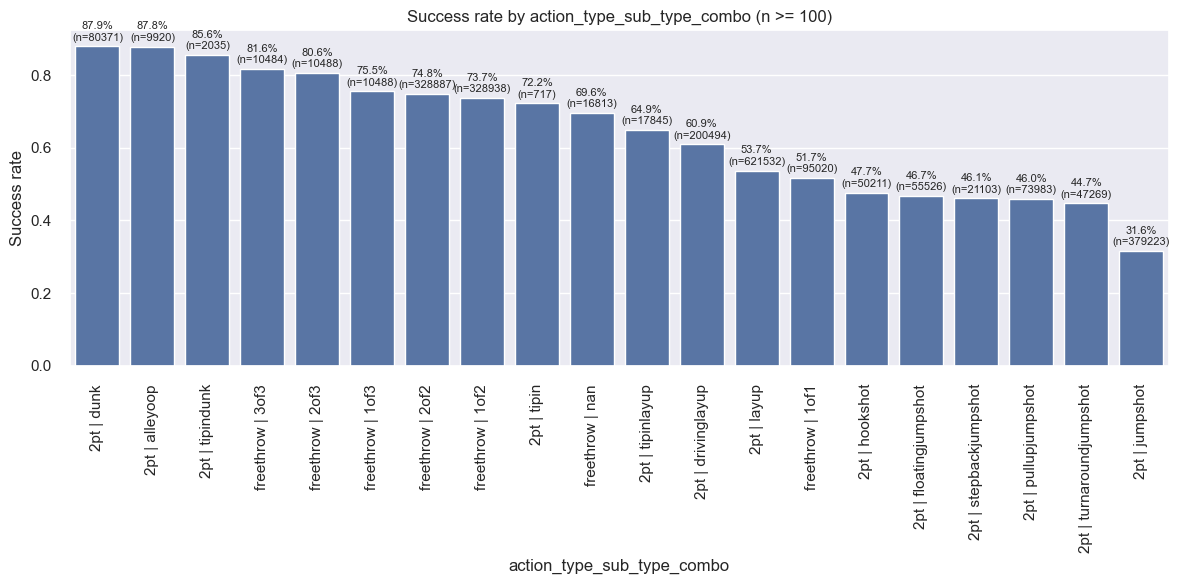

In [8]:
# Visualize success rate by action_type/sub_type combination (bar plot)

if not rate_table.empty:
    plot_df = rate_table.reset_index()
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=plot_df,
        x=FEATURE_COMBO_COL,
        y="success_rate",
        order=plot_df[FEATURE_COMBO_COL],
    )
    plt.xticks(rotation=90)
    plt.ylabel("Success rate")
    plt.title(f"Success rate by {FEATURE_COMBO_COL} (n >= {MIN_N})")

    # Add exact % and n on top of each bar
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        n_val = plot_df.loc[i, "n"]
        pct_val = plot_df.loc[i, "success_rate"] * 100
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.01,  # a bit above the bar
            f"{pct_val:.1f}%\n(n={n_val})",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()
else:
    print("rate_table is empty after applying minimum-n filter; check FEATURE_COMBO_COL/TARGET_COL or data filtering.")


In [9]:
# Crosstab of action_type/sub_type combination vs target (only combinations with sufficient n)

valid_combos = rate_table.index
filtered_df = model_df[model_df[FEATURE_COMBO_COL].isin(valid_combos)]

# Number of distinct action_type/sub_type combos with sample size >= MIN_N
print(f"Number of {FEATURE_COMBO_COL} combinations with n >= {MIN_N}: {len(valid_combos)}")

ct = pd.crosstab(filtered_df[FEATURE_COMBO_COL], filtered_df[TARGET_COL], dropna=False)
print("Crosstab (counts):")
print(ct)

print("\nCrosstab (row-wise proportions):")
print(ct.div(ct.sum(axis=1), axis=0))


Number of action_type_sub_type_combo combinations with n >= 100: 20
Crosstab (counts):
success                      False   True 
action_type_sub_type_combo                
2pt | alleyoop                1211    8709
2pt | drivinglayup           78353  122141
2pt | dunk                    9752   70619
2pt | floatingjumpshot       29593   25933
2pt | hookshot               26281   23930
2pt | jumpshot              259285  119938
2pt | layup                 287895  333637
2pt | pullupjumpshot         39973   34010
2pt | stepbackjumpshot       11381    9722
2pt | tipin                    199     518
2pt | tipindunk                294    1741
2pt | tipinlayup              6269   11576
2pt | turnaroundjumpshot     26147   21122
freethrow | 1of1             45904   49116
freethrow | 1of2             86649  242289
freethrow | 1of3              2573    7915
freethrow | 2of2             82888  245999
freethrow | 2of3              2035    8453
freethrow | 3of3              1925    8559
freethrow 

## Next steps / ideas

- Adjust `ACTION_COL`, `SUBTYPE_COL`, or `TARGET_COL` if your column names differ.
- Group or filter combined action_type/sub_type categories (e.g., minimum count threshold) before plotting.
- Add statistical tests (e.g., chi-squared) to quantify association between combined action/sub_type and success.
- Save any cleaned or feature-engineered versions of the dataset to `data/processed/` for modeling notebooks.


## Additional dataset: NCAAM 2024–2026 shots

In this section we load `~/ncaam_24_25_26_shots.csv`, parse the JSON-like `ev` column to extract `initial_ev.value`, and derive a per-shot `predicted_shot_proba` based on the shot type (3pt/2pt/freethrow).



In [10]:
# Load 2024–2026 shots dataset and derive predicted_shot_proba

shots_path = os.path.expanduser("~/ncaam_24_25_26_shots.csv")
shots_df = pd.read_csv(shots_path)

print("Loaded shots_df shape:", shots_df.shape)
print("Columns:", list(shots_df.columns))

# Helper to safely extract initial_ev.value from the ev JSON-like column
import json

def extract_initial_ev_value(ev_raw):
    """Extract initial_ev.value from an ev JSON string/dict; return np.nan if unavailable."""
    if pd.isna(ev_raw):
        return np.nan
    try:
        # If already a dict-like, use as-is; otherwise try to parse as JSON string
        if isinstance(ev_raw, (dict, list)):
            ev_obj = ev_raw
        else:
            ev_obj = json.loads(ev_raw)
        # Expected structure: {"live_ev": {...}, "dynamic_ev": {...}, "initial_ev": {"value": x, ...}}
        initial_ev = ev_obj.get("initial_ev", {})
        return initial_ev.get("value", np.nan)
    except Exception:
        return np.nan

# Create column with raw initial_ev value
shots_df["initial_ev_value"] = shots_df["ev"].apply(extract_initial_ev_value)

# Derive predicted_shot_proba by normalizing initial_ev_value by points for the shot type
# - divide by 3 if action_type == "3pt"
# - divide by 2 if action_type == "2pt"
# - keep as-is if action_type == "freethrow"

POINTS_MAP = {"3pt": 3, "2pt": 2, "freethrow": 1}

points = shots_df["action_type"].map(POINTS_MAP)
shots_df["predicted_shot_proba"] = shots_df["initial_ev_value"] / points

print("\nPreview of derived columns:")
shots_df[["action_type", "ev", "initial_ev_value", "predicted_shot_proba"]].head()


/var/folders/xt/tmf1146d7290zvg92b_crg080000gn/T/ipykernel_1923/2928573460.py:4: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  shots_df = pd.read_csv(shots_path)


Loaded shots_df shape: (1025915, 27)
Columns: ['game_id', 'parent_play_id', 'play_id', 'team_id', 'player_id', 'period', 'minutes', 'seconds', 'made', 'action_type', 'play_descriptors', 'shot_x', 'shot_y', 'contest_score', 'spacing', 'shooting_bench_direction', 'created_at', 'updated_at', 'feature_store', 'feature_store_top_5', 'feature_store_created_at', 'feature_store_updated_at', 'ev', 'shot_taking', 'dynamic_updated_at', 'initial_updated_at', 'live_updated_at']

Preview of derived columns:


,action_type,ev,initial_ev_value,predicted_shot_proba
0,2pt,"{""live_ev"": {""value"": null, ""updated_at"": null...",0.605718,0.302859
1,2pt,"{""live_ev"": {""value"": null, ""updated_at"": null...",0.914746,0.457373
2,2pt,"{""live_ev"": {""value"": null, ""updated_at"": null...",0.647064,0.323532
3,2pt,"{""live_ev"": {""value"": null, ""updated_at"": null...",1.645126,0.822563
4,3pt,"{""live_ev"": {""value"": null, ""updated_at"": null...",0.970702,0.323567


In [11]:
# Compute Brier score for predicted_shot_proba vs made outcome

# Ensure we drop rows with missing prediction or outcome
mask = shots_df["predicted_shot_proba"].notna() & shots_df["made"].notna()

y_true = shots_df.loc[mask, "made"].astype(int)
y_prob = shots_df.loc[mask, "predicted_shot_proba"].astype(float)

brier_score = np.mean((y_prob - y_true) ** 2)
print(f"Brier score (predicted_shot_proba vs made): {brier_score:.6f}")



Brier score (predicted_shot_proba vs made): 0.212383


## Naive combo-based model with time-based train/test split

Here we build a naive model that predicts shot success as the historical average success rate for each `action_type/sub_type` combination.

- **Train set**: rows with `time_actual` strictly before 2024-06-01.
- **Test set**: rows with `time_actual` on or after 2024-06-01.
- **Prediction**: for each combo, use the train-set mean of `success`; unseen combos in test fall back to the global train-set mean.
- **Evaluation**: report Brier score and accuracy on the test period.


In [12]:
# Naive combo-based model with time-based train/test split

# Ensure time_actual is parsed as datetime and normalized to a common timezone (UTC)
df_with_time = df.copy()
df_with_time["time_actual"] = pd.to_datetime(df_with_time["time_actual"], utc=True)

# Rebuild combo column on this full frame to keep things explicit
df_with_time[FEATURE_COMBO_COL] = (
    df_with_time[ACTION_COL].astype(str) + " | " + df_with_time[SUBTYPE_COL].astype(str)
)

# Drop rows with missing target
df_with_time = df_with_time.dropna(subset=[TARGET_COL])

# Define time-based split: before vs on/after 2024-06-01 (also UTC)
split_date = pd.Timestamp("2024-06-01", tz="UTC")
train_mask = df_with_time["time_actual"] < split_date
test_mask = df_with_time["time_actual"] >= split_date

train_df = df_with_time[train_mask].copy()
test_df = df_with_time[test_mask].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Compute naive per-combo success rate on the train set
combo_stats = (
    train_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
    .mean()
    .rename("combo_success_rate")
)

# Global mean as fallback for unseen combos
global_mean = train_df[TARGET_COL].mean()
print("Global train success rate:", global_mean)

# Attach predictions to test set
test_df = test_df.join(combo_stats, on=FEATURE_COMBO_COL)
# Fill missing combos with global mean
test_df["combo_success_rate"].fillna(global_mean, inplace=True)

# Evaluate on test set (Brier score + accuracy)
y_true_test = test_df[TARGET_COL].astype(int).values
y_prob_test = test_df["combo_success_rate"].astype(float).values

brier_test = np.mean((y_prob_test - y_true_test) ** 2)
y_pred_label = (y_prob_test >= 0.5).astype(int)
accuracy_test = (y_pred_label == y_true_test).mean()

print(f"Brier score on test period: {brier_test:.6f}")
print(f"Accuracy on test period: {accuracy_test:.4f}")


Train shape: (2283315, 33)
Test shape: (1034450, 33)
Global train success rate: 0.5040206892172127
Brier score on test period: 0.220282
Accuracy on test period: 0.6482


/var/folders/xt/tmf1146d7290zvg92b_crg080000gn/T/ipykernel_1923/768963001.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["combo_success_rate"].fillna(global_mean, inplace=True)


In [13]:
# Brier score and accuracy on training period for naive combo-based model

# Use the same combo_stats (train-set means) to generate in-sample predictions
train_with_preds = train_df.join(combo_stats, on=FEATURE_COMBO_COL)

y_true_train = train_with_preds[TARGET_COL].astype(int).values
y_prob_train = train_with_preds["combo_success_rate"].astype(float).values

brier_train = np.mean((y_prob_train - y_true_train) ** 2)
y_pred_train_label = (y_prob_train >= 0.5).astype(int)
accuracy_train = (y_pred_train_label == y_true_train).mean()

print(f"Brier score on training period: {brier_train:.6f}")
print(f"Accuracy on training period: {accuracy_train:.4f}")


Brier score on training period: 0.220804
Accuracy on training period: 0.6476


## Compare test Brier scores: Naive model vs SQ API

We now compare the **test-period** Brier score from the naive combo-based model to the Brier score from the SQ API (`predicted_shot_proba`) on NCAAM 2024/25–2025/26 data.


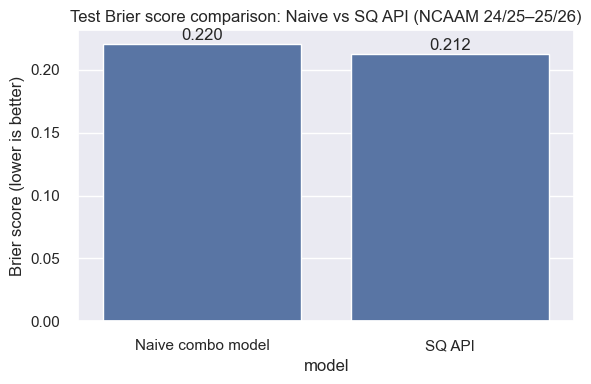

In [14]:
# Bar chart comparing test Brier scores: Naive model vs SQ API

# We assume:
# - brier_test: test-period Brier score from the naive combo-based model
# - brier_score: Brier score from SQ API predictions (predicted_shot_proba vs made)

comparison_df = pd.DataFrame({
    "model": ["Naive combo model", "SQ API"],
    "brier_score": [brier_test, brier_score],
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=comparison_df, x="model", y="brier_score")
plt.ylabel("Brier score (lower is better)")
plt.title("Test Brier score comparison: Naive vs SQ API (NCAAM 24/25–25/26)")

# Annotate exact values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## Per-combo logistic regression model using qualifiers

Here we try a richer model that, for **each** `action_type/sub_type` combination, trains a **logistic regression** model on the training period.

- Each per-combo model uses:
  - The **average success rate** for that combo in the training set (a scalar feature), and
  - The **`qualifiers` text** for that combo, vectorized with a simple bag-of-words representation.
- We train only on combos with a minimum sample size and evaluate on the held-out test period (on matching combos).


In [15]:
# Per-combo logistic regression using combo avg success + qualifiers

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

# Ensure qualifiers exists and is string-typed on train/test splits
for df_ in (train_df, test_df):
    if "qualifiers" not in df_.columns:
        # If qualifiers is missing from the split, merge back from original df
        df_merged = df_.merge(df[["match_id", "action_number", "qualifiers"]],
                              on=["match_id", "action_number"], how="left")
        df_.loc[:, "qualifiers"] = df_merged["qualifiers"]
    df_["qualifiers"] = df_["qualifiers"].fillna("").astype(str)

MIN_N_LOGIT = 500  # minimum train rows per combo to fit a model

combo_models = {}
combo_vectorizers = {}
logit_results = []

for combo, combo_train in train_df.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT:
        continue

    combo_test = test_df[test_df[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Compute average success rate for this combo on the training data
    combo_mean = combo_train[TARGET_COL].mean()

    combo_train = combo_train.copy()
    combo_test = combo_test.copy()
    combo_train["combo_avg_success"] = combo_mean
    combo_test["combo_avg_success"] = combo_mean

    # Text features from qualifiers
    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train["qualifiers"])
    except ValueError:
        # This can happen if all documents are empty/stop words -> empty vocabulary
        # Skip training a model for this combo.
        continue
    Xq_test = vect.transform(combo_test["qualifiers"])

    # Numeric feature: combo average success (single column)
    Xnum_train = combo_train[["combo_avg_success"]].values
    Xnum_test = combo_test[["combo_avg_success"]].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Test predictions
    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]
    brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
    acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

    # Train predictions
    y_prob_train_combo = clf.predict_proba(X_train)[:, 1]
    brier_train_combo = np.mean((y_prob_train_combo - y_train) ** 2)
    acc_train_combo = ((y_prob_train_combo >= 0.5).astype(int) == y_train).mean()

    logit_results.append(
        {
            "combo": combo,
            "n_train": len(combo_train),
            "n_test": len(combo_test),
            "brier_test": brier_test_combo,
            "accuracy_test": acc_test_combo,
            "brier_train": brier_train_combo,
            "accuracy_train": acc_train_combo,
        }
    )

    combo_models[combo] = clf
    combo_vectorizers[combo] = vect

logit_results_df = pd.DataFrame(logit_results).sort_values("brier_test")

print("Per-combo logistic regression results (best TEST Brier score first):")
print(logit_results_df.head(20))

if not logit_results_df.empty:
    total_n_test = logit_results_df["n_test"].sum()
    total_n_train = logit_results_df["n_train"].sum()

    weighted_brier_test = (logit_results_df["brier_test"] * logit_results_df["n_test"]).sum() / total_n_test
    weighted_acc_test = (logit_results_df["accuracy_test"] * logit_results_df["n_test"]).sum() / total_n_test

    weighted_brier_train = (logit_results_df["brier_train"] * logit_results_df["n_train"]).sum() / total_n_train
    weighted_acc_train = (logit_results_df["accuracy_train"] * logit_results_df["n_train"]).sum() / total_n_train

    print("\nOverall weighted TEST metrics across combos with models:")
    print(f"Weighted Brier score (test): {weighted_brier_test:.6f}")
    print(f"Weighted accuracy (test): {weighted_acc_test:.4f}")

    print("\nOverall weighted TRAIN metrics across combos with models:")
    print(f"Weighted Brier score (train): {weighted_brier_train:.6f}")
    print(f"Weighted accuracy (train): {weighted_acc_train:.4f}")
else:
    print("No combos met the minimum sample size for logistic regression.")



Per-combo logistic regression results (best TEST Brier score first):
                       combo  n_train  n_test  brier_test  accuracy_test  \
2                 2pt | dunk    55886   24485    0.068446       0.922034   
0             2pt | alleyoop     6178    3742    0.102030       0.880011   
18          freethrow | 3of3     6853    3631    0.148429       0.818783   
17          freethrow | 2of3     6855    3633    0.153252       0.811175   
15          freethrow | 1of3     6855    3633    0.181696       0.761905   
1         2pt | drivinglayup   128153   72341    0.186940       0.694392   
16          freethrow | 2of2   219584  109303    0.187673       0.749394   
6                2pt | layup   444903  176629    0.190785       0.661885   
14          freethrow | 1of2   219615  109323    0.193493       0.737228   
5             2pt | jumpshot   287388   91835    0.204312       0.692100   
10            3pt | jumpshot   627479  287480    0.209076       0.693641   
11      3pt | pullu

## Compare Brier scores: SQ API vs per-combo logistic model

Here we compare the overall test-period Brier score from the SQ API (`predicted_shot_proba`) to the weighted test Brier score from the per-combo logistic regression model that uses qualifiers.


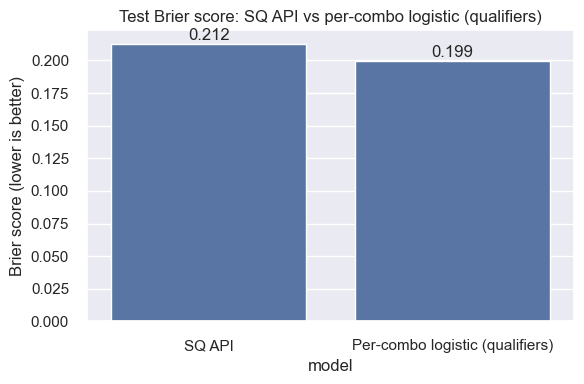

In [16]:
# Bar chart comparing Brier scores: SQ API vs per-combo logistic model

# We assume:
# - brier_score: Brier score from SQ API predictions (shots_df, predicted_shot_proba vs made)
# - weighted_brier_test: weighted test-period Brier score from per-combo logistic model

comparison_logit_df = pd.DataFrame({
    "model": ["SQ API", "Per-combo logistic (qualifiers)"],
    "brier_score": [brier_score, weighted_brier_test],
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=comparison_logit_df, x="model", y="brier_score")
plt.ylabel("Brier score (lower is better)")
plt.title("Test Brier score: SQ API vs per-combo logistic (qualifiers)")

# Annotate exact values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## Per-combo logistic regression with qualifiers + shot_distance

Here we extend the per-combo logistic regression model to include **shot_distance** as an additional numeric feature, alongside:

- The **average success rate** for that combo in the training set (scalar feature), and
- The **`qualifiers` text** (bag-of-words).

We restrict to rows where `shot_distance` is available (non-NaN and non-zero) for both train and test within each combo and report weighted Brier/accuracy across combos.


In [17]:
# Per-combo logistic regression using combo avg success + qualifiers + shot_distance

from scipy.sparse import hstack

MIN_N_LOGIT_SD = 500  # minimum train rows per combo to fit a model (same threshold)

combo_models_sd = {}
combo_vectorizers_sd = {}
logit_results_sd = []

for combo, combo_train in train_df.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_SD:
        continue

    combo_test = test_df[test_df[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Restrict to rows with valid shot_distance in both train and test
    combo_train = combo_train[combo_train["shot_distance"].notna() & (combo_train["shot_distance"] != 0)].copy()
    combo_test = combo_test[combo_test["shot_distance"].notna() & (combo_test["shot_distance"] != 0)].copy()

    if len(combo_train) < MIN_N_LOGIT_SD or combo_test.empty:
        continue

    # Compute average success rate for this combo on the (filtered) training data
    combo_mean = combo_train[TARGET_COL].mean()

    combo_train["combo_avg_success"] = combo_mean
    combo_test["combo_avg_success"] = combo_mean

    # Ensure qualifiers is present and string-typed (reuse same logic as before)
    for df_ in (combo_train, combo_test):
        if "qualifiers" not in df_.columns:
            df_["qualifiers"] = ""
        df_["qualifiers"] = df_["qualifiers"].fillna("").astype(str)

    # Text features from qualifiers
    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train["qualifiers"])
    except ValueError:
        # This can happen if all documents are empty/stop words -> empty vocabulary
        # Skip training a model for this combo.
        continue
    Xq_test = vect.transform(combo_test["qualifiers"])

    # Numeric features: combo average success + shot_distance
    Xnum_train = combo_train[["combo_avg_success", "shot_distance"]].values
    Xnum_test = combo_test[["combo_avg_success", "shot_distance"]].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Test predictions
    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]
    brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
    acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

    # Train predictions
    y_prob_train_combo = clf.predict_proba(X_train)[:, 1]
    brier_train_combo = np.mean((y_prob_train_combo - y_train) ** 2)
    acc_train_combo = ((y_prob_train_combo >= 0.5).astype(int) == y_train).mean()

    logit_results_sd.append(
        {
            "combo": combo,
            "n_train": len(combo_train),
            "n_test": len(combo_test),
            "brier_test": brier_test_combo,
            "accuracy_test": acc_test_combo,
            "brier_train": brier_train_combo,
            "accuracy_train": acc_train_combo,
        }
    )

    combo_models_sd[combo] = clf
    combo_vectorizers_sd[combo] = vect

logit_results_sd_df = pd.DataFrame(logit_results_sd).sort_values("brier_test")

print("Per-combo logistic regression with shot_distance (best TEST Brier score first):")
print(logit_results_sd_df.head(20))

if not logit_results_sd_df.empty:
    total_n_test_sd = logit_results_sd_df["n_test"].sum()
    total_n_train_sd = logit_results_sd_df["n_train"].sum()

    weighted_brier_test_sd = (logit_results_sd_df["brier_test"] * logit_results_sd_df["n_test"]).sum() / total_n_test_sd
    weighted_acc_test_sd = (logit_results_sd_df["accuracy_test"] * logit_results_sd_df["n_test"]).sum() / total_n_test_sd

    weighted_brier_train_sd = (logit_results_sd_df["brier_train"] * logit_results_sd_df["n_train"]).sum() / total_n_train_sd
    weighted_acc_train_sd = (logit_results_sd_df["accuracy_train"] * logit_results_sd_df["n_train"]).sum() / total_n_train_sd

    print("\nOverall weighted TEST metrics across combos with models (with shot_distance):")
    print(f"Weighted Brier score (test): {weighted_brier_test_sd:.6f}")
    print(f"Weighted accuracy (test): {weighted_acc_test_sd:.4f}")

    print("\nOverall weighted TRAIN metrics across combos with models (with shot_distance):")
    print(f"Weighted Brier score (train): {weighted_brier_train_sd:.6f}")
    print(f"Weighted accuracy (train): {weighted_acc_train_sd:.4f}")
else:
    print("No combos met the minimum sample size for logistic regression with shot_distance.")



Per-combo logistic regression with shot_distance (best TEST Brier score first):
                       combo  n_train  n_test  brier_test  accuracy_test  \
2                 2pt | dunk    54193   24446    0.067904       0.921869   
0             2pt | alleyoop     6169    3742    0.100168       0.879476   
1         2pt | drivinglayup   127829   72337    0.184048       0.697278   
6                2pt | layup   428194  176192    0.185488       0.685888   
5             2pt | jumpshot   273729   91517    0.204259       0.692079   
10            3pt | jumpshot   607609  287032    0.208944       0.693682   
11      3pt | pullupjumpshot    16084    9130    0.217987       0.664951   
12    3pt | stepbackjumpshot     9201    6542    0.234220       0.619535   
3     2pt | floatingjumpshot    34553   20959    0.236693       0.556897   
9   2pt | turnaroundjumpshot    31032   16153    0.237361       0.571968   
4             2pt | hookshot    35274   14895    0.238389       0.561531   
7       

## Compare Brier scores: SQ API vs per-combo logistic (with shot_distance)

Here we compare the **test-period** Brier score from the SQ API (`predicted_shot_proba`) to the weighted test Brier score from the per-combo logistic regression model that uses qualifiers **plus shot_distance**.


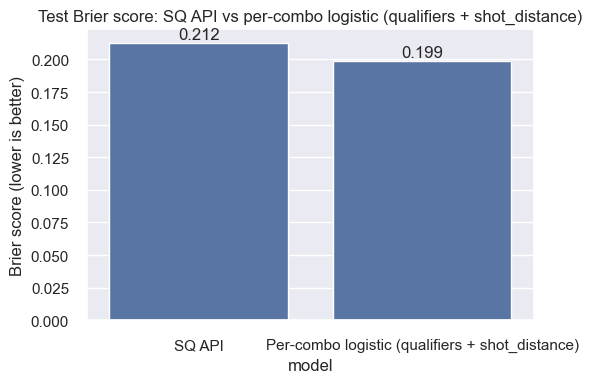

In [18]:
# Bar chart comparing Brier scores: SQ API vs per-combo logistic (qualifiers + shot_distance)

# We assume:
# - brier_score: Brier score from SQ API predictions (shots_df, predicted_shot_proba vs made)
# - weighted_brier_test_sd: weighted test-period Brier score from per-combo logistic model with shot_distance

comparison_sd_df = pd.DataFrame({
    "model": ["SQ API", "Per-combo logistic (qualifiers + shot_distance)"],
    "brier_score": [brier_score, weighted_brier_test_sd],
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=comparison_sd_df, x="model", y="brier_score")
plt.ylabel("Brier score (lower is better)")
plt.title("Test Brier score: SQ API vs per-combo logistic (qualifiers + shot_distance)")

# Annotate exact values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


In [19]:
# Inspect distinct sub_type values

unique_sub_types = sorted(df["sub_type"].dropna().unique())
print("Distinct sub_type values (sorted):")
for v in unique_sub_types:
    print(f"- {v}")


Distinct sub_type values (sorted):
- 1of1
- 1of2
- 1of3
- 2of2
- 2of3
- 3of3
- alleyoop
- drivinglayup
- dunk
- floatingjumpshot
- hookshot
- jumpshot
- layup
- pullupjumpshot
- stepbackjumpshot
- tipin
- tipindunk
- tipinlayup
- turnaroundjumpshot
- wrongbasket


## Player-specific Bayesian priors by action/sub_type combo

We now build **player-specific shooting priors** for each `person_id` and `action_type/sub_type` combination using a Beta–Bernoulli empirical Bayes approach on the **training period only**:

- For each combo, compute the global train-set make rate.
- For each player+combo, update a `Beta(α_prior, β_prior)` prior (with a tunable pseudo-shot strength) using that player's makes/misses.
- The resulting posterior mean becomes a **player prior feature** we can feed into the per-combo logistic regressions.

We will then tune the pseudo-shot strength by minimizing the **test Brier score** when player priors are included as a feature.


In [20]:
# Player priors by person_id + action_type/sub_type combo with tuning over pseudo-shot strength

# We operate on the existing train_df / test_df split and FEATURE_COMBO_COL, TARGET_COL.
# For each prior_strength value, we:
# 1) Build player-specific Beta-Bernoulli priors on the TRAIN period only.
# 2) Add the posterior mean as a numeric feature (player_prior_mean) to both train and test.
# 3) Train per-combo logistic models (combo_avg_success + qualifiers + player_prior_mean).
# 4) Compute weighted test Brier score to pick the best prior_strength.

PRIOR_STRENGTH_GRID = [50, 100, 200, 500]
MIN_N_LOGIT_PRIOR = 500  # minimum train rows per combo for these models

# Global combo-level stats on the training set (used to center priors)
combo_global = (
    train_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
    .agg(global_makes="sum", global_attempts="count")
)
combo_global["global_rate"] = combo_global["global_makes"] / combo_global["global_attempts"]

prior_grid_results = []

for prior_strength in PRIOR_STRENGTH_GRID:
    print(f"\n=== Fitting models with prior_strength = {prior_strength} pseudo-shots ===")

    # Player-level counts by person_id + combo on the TRAIN period
    priors = (
        train_df.groupby(["person_id", FEATURE_COMBO_COL])[TARGET_COL]
        .agg(player_makes="sum", player_attempts="count")
        .reset_index()
    )

    # Merge in global combo rate
    priors = priors.merge(
        combo_global[["global_rate"]],
        left_on=FEATURE_COMBO_COL,
        right_index=True,
        how="left",
    )

    # Empirical Bayes Beta prior centered on global_rate with total mass = prior_strength
    priors["alpha_prior"] = priors["global_rate"] * prior_strength
    priors["beta_prior"] = (1.0 - priors["global_rate"]) * prior_strength

    # Posterior parameters and mean
    priors["alpha_post"] = priors["alpha_prior"] + priors["player_makes"]
    priors["beta_post"] = priors["beta_prior"] + (
        priors["player_attempts"] - priors["player_makes"]
    )
    priors["player_prior_mean"] = priors["alpha_post"] / (
        priors["alpha_post"] + priors["beta_post"]
    )

    # Attach player_prior_mean to train/test splits
    key_cols = ["person_id", FEATURE_COMBO_COL]
    prior_feat = priors[key_cols + ["player_prior_mean"]]

    train_ps = train_df.merge(prior_feat, on=key_cols, how="left")
    test_ps = test_df.merge(prior_feat, on=key_cols, how="left")

    logit_results_prior = []

    for combo, combo_train in train_ps.groupby(FEATURE_COMBO_COL):
        if len(combo_train) < MIN_N_LOGIT_PRIOR:
            continue

        combo_test = test_ps[test_ps[FEATURE_COMBO_COL] == combo]
        if combo_test.empty:
            continue

        combo_train = combo_train.copy()
        combo_test = combo_test.copy()

        # Compute average success rate for this combo on the training data
        combo_mean = combo_train[TARGET_COL].mean()
        combo_train["combo_avg_success"] = combo_mean
        combo_test["combo_avg_success"] = combo_mean

        # Ensure qualifiers exists and is string-typed; fill missing player priors with combo_mean
        for df_ in (combo_train, combo_test):
            if "qualifiers" not in df_.columns:
                df_["qualifiers"] = ""
            df_["qualifiers"] = df_["qualifiers"].fillna("").astype(str)
            df_["player_prior_mean"] = df_["player_prior_mean"].fillna(combo_mean)

        # Text features from qualifiers
        vect = CountVectorizer(binary=True, min_df=5)
        try:
            Xq_train = vect.fit_transform(combo_train["qualifiers"])
        except ValueError:
            # Empty vocabulary (e.g., all empty strings); skip this combo.
            continue
        Xq_test = vect.transform(combo_test["qualifiers"])

        # Numeric features: combo average success + player_prior_mean
        Xnum_train = combo_train[["combo_avg_success", "player_prior_mean"]].values
        Xnum_test = combo_test[["combo_avg_success", "player_prior_mean"]].values

        X_train = hstack([Xnum_train, Xq_train])
        X_test = hstack([Xnum_test, Xq_test])

        y_train = combo_train[TARGET_COL].astype(int).values
        y_test = combo_test[TARGET_COL].astype(int).values

        clf = LogisticRegression(max_iter=200, n_jobs=-1)
        clf.fit(X_train, y_train)

        # Test predictions
        y_prob_test_combo = clf.predict_proba(X_test)[:, 1]
        brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
        acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

        # Train predictions
        y_prob_train_combo = clf.predict_proba(X_train)[:, 1]
        brier_train_combo = np.mean((y_prob_train_combo - y_train) ** 2)
        acc_train_combo = ((y_prob_train_combo >= 0.5).astype(int) == y_train).mean()

        logit_results_prior.append(
            {
                "combo": combo,
                "n_train": len(combo_train),
                "n_test": len(combo_test),
                "brier_test": brier_test_combo,
                "accuracy_test": acc_test_combo,
                "brier_train": brier_train_combo,
                "accuracy_train": acc_train_combo,
            }
        )

    logit_results_prior_df = pd.DataFrame(logit_results_prior)

    if logit_results_prior_df.empty:
        print("No combos met the minimum sample size with player priors; skipping this prior_strength.")
        continue

    total_n_test_prior = logit_results_prior_df["n_test"].sum()
    total_n_train_prior = logit_results_prior_df["n_train"].sum()

    weighted_brier_test_prior = (
        logit_results_prior_df["brier_test"] * logit_results_prior_df["n_test"]
    ).sum() / total_n_test_prior
    weighted_acc_test_prior = (
        logit_results_prior_df["accuracy_test"] * logit_results_prior_df["n_test"]
    ).sum() / total_n_test_prior

    weighted_brier_train_prior = (
        logit_results_prior_df["brier_train"] * logit_results_prior_df["n_train"]
    ).sum() / total_n_train_prior
    weighted_acc_train_prior = (
        logit_results_prior_df["accuracy_train"] * logit_results_prior_df["n_train"]
    ).sum() / total_n_train_prior

    prior_grid_results.append(
        {
            "prior_strength": prior_strength,
            "weighted_brier_test": weighted_brier_test_prior,
            "weighted_accuracy_test": weighted_acc_test_prior,
            "weighted_brier_train": weighted_brier_train_prior,
            "weighted_accuracy_train": weighted_acc_train_prior,
        }
    )

    print("Weighted Brier (TEST):", weighted_brier_test_prior)
    print("Weighted accuracy (TEST):", weighted_acc_test_prior)
    print("Weighted Brier (TRAIN):", weighted_brier_train_prior)
    print("Weighted accuracy (TRAIN):", weighted_acc_train_prior)

prior_grid_df = pd.DataFrame(prior_grid_results).sort_values("weighted_brier_test")
print("\nPrior strength grid search results (sorted by TEST Brier ascending):")
print(prior_grid_df)

if not prior_grid_df.empty:
    best_row = prior_grid_df.iloc[0]
    print(
        f"\nBest prior_strength by TEST Brier: {best_row['prior_strength']} "
        f"(Brier={best_row['weighted_brier_test']:.6f}, "
        f"Accuracy={best_row['weighted_accuracy_test']:.4f})"
    )



=== Fitting models with prior_strength = 50 pseudo-shots ===
Weighted Brier (TEST): 0.1999926111517725
Weighted accuracy (TEST): 0.6878912994816037
Weighted Brier (TRAIN): 0.19373714538411713
Weighted accuracy (TRAIN): 0.7020705196556813

=== Fitting models with prior_strength = 100 pseudo-shots ===
Weighted Brier (TEST): 0.1995869187191095
Weighted accuracy (TEST): 0.6888004898978295
Weighted Brier (TRAIN): 0.19458028671433777
Weighted accuracy (TRAIN): 0.7009234674782683

=== Fitting models with prior_strength = 200 pseudo-shots ===
Weighted Brier (TEST): 0.19932005662041377
Weighted accuracy (TEST): 0.689358626313864
Weighted Brier (TRAIN): 0.195410724397708
Weighted accuracy (TRAIN): 0.6993412504501705

=== Fitting models with prior_strength = 500 pseudo-shots ===
Weighted Brier (TEST): 0.19908509713002978
Weighted accuracy (TEST): 0.6897639161848713
Weighted Brier (TRAIN): 0.19656869171681582
Weighted accuracy (TRAIN): 0.696829563670002

Prior strength grid search results (sorted

## Per-combo logistic regression with all features (player prior + qualifiers + shot_distance + team_advantage)

We now build a **unified per-combo logistic regression model** that uses all of the engineered features:

- **Combo average success rate** (per `action_type/sub_type` combo on the training period)
- **Player prior** (Beta–Bernoulli empirical Bayes mean for `person_id` + combo, from the training period)
- **Shot distance** (in feet, where available and non-zero)
- **Team advantage** (Power 5 vs non–Power 5; encoded numerically)
- **Qualifiers text** (bag-of-words representation)

We restrict to combos with sufficient sample size and rows where `shot_distance` is defined, then report **weighted test Brier score and accuracy** across all combos with models.



Using prior_strength = 500.0 for player priors
Per-combo logistic regression with all features (best TEST Brier score first):
                       combo  n_train  n_test  brier_test  accuracy_test  \
2                 2pt | dunk    54193   24446    0.073920       0.921787   
0             2pt | alleyoop     6169    3742    0.103567       0.879743   
6                2pt | layup   428194  176192    0.190132       0.678822   
10            3pt | jumpshot   607609  287032    0.208861       0.693686   
5             2pt | jumpshot   273729   91517    0.212056       0.692079   
1         2pt | drivinglayup   127829   72337    0.222054       0.696462   
11      3pt | pullupjumpshot    16084    9130    0.227904       0.664951   
12    3pt | stepbackjumpshot     9201    6542    0.233248       0.619535   
3     2pt | floatingjumpshot    34553   20959    0.237850       0.568395   
4             2pt | hookshot    35274   14895    0.240251       0.554951   
8     2pt | stepbackjumpshot    14034 

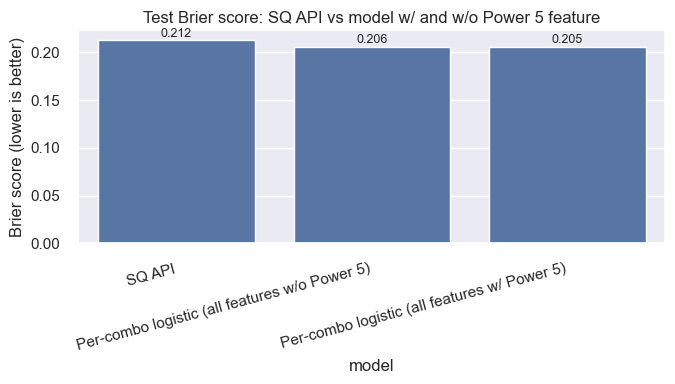

In [21]:
# Per-combo logistic regression using all features (combo avg success + player prior + qualifiers + shot_distance + team_advantage)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

# Choose best prior_strength from the earlier grid search (fall back to 500 if missing)
if 'prior_grid_df' in globals() and not prior_grid_df.empty:
    best_prior_strength = float(prior_grid_df.sort_values('weighted_brier_test').iloc[0]['prior_strength'])
else:
    best_prior_strength = 500.0

print(f"Using prior_strength = {best_prior_strength} for player priors")

MIN_N_LOGIT_ALL = 500  # minimum train rows per combo to fit a model

# Recompute combo-level global stats on the training set
combo_global_all = (
    train_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
    .agg(global_makes='sum', global_attempts='count')
)
combo_global_all['global_rate'] = combo_global_all['global_makes'] / combo_global_all['global_attempts']

# Player-level counts by person_id + combo on the TRAIN period
priors_all = (
    train_df.groupby(['person_id', FEATURE_COMBO_COL])[TARGET_COL]
    .agg(player_makes='sum', player_attempts='count')
    .reset_index()
)

# Merge in global combo rate
priors_all = priors_all.merge(
    combo_global_all[['global_rate']],
    left_on=FEATURE_COMBO_COL,
    right_index=True,
    how='left',
)

# Empirical Bayes Beta prior centered on global_rate with total mass = best_prior_strength
priors_all['alpha_prior'] = priors_all['global_rate'] * best_prior_strength
priors_all['beta_prior'] = (1.0 - priors_all['global_rate']) * best_prior_strength

priors_all['alpha_post'] = priors_all['alpha_prior'] + priors_all['player_makes']
priors_all['beta_post'] = priors_all['alpha_prior'] + (
    priors_all['player_attempts'] - priors_all['player_makes']
)
priors_all['player_prior_mean'] = priors_all['alpha_post'] / (
    priors_all['alpha_post'] + priors_all['beta_post']
)

# Attach player_prior_mean to train/test splits
key_cols_all = ['person_id', FEATURE_COMBO_COL]
prior_feat_all = priors_all[key_cols_all + ['player_prior_mean']]

train_all = train_df.merge(prior_feat_all, on=key_cols_all, how='left')
test_all = test_df.merge(prior_feat_all, on=key_cols_all, how='left')

# Container for per-combo results (WITH team_advantage feature)
logit_results_all = []

for combo, combo_train in train_all.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_ALL:
        continue

    combo_test = test_all[test_all[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Restrict to rows with valid shot_distance in both train and test
    combo_train = combo_train[
        combo_train['shot_distance'].notna() & (combo_train['shot_distance'] != 0)
    ].copy()
    combo_test = combo_test[
        combo_test['shot_distance'].notna() & (combo_test['shot_distance'] != 0)
    ].copy()

    if len(combo_train) < MIN_N_LOGIT_ALL or combo_test.empty:
        continue

    # Compute average success rate for this combo on the (filtered) training data
    combo_mean = combo_train[TARGET_COL].mean()
    combo_train['combo_avg_success'] = combo_mean
    combo_test['combo_avg_success'] = combo_mean

    # Prepare team_advantage as numeric feature: True -> 1, False -> -1, NA -> 0
    for df_ in (combo_train, combo_test):
        if 'team_advantage' not in df_.columns:
            df_['team_advantage'] = pd.NA
        df_['team_advantage_num'] = (
            df_['team_advantage']
            .map({True: 1.0, False: -1.0})
            .fillna(0.0)
            .astype(float)
        )

    # Ensure qualifiers exists and is string-typed; fill missing player priors with combo_mean
    for df_ in (combo_train, combo_test):
        if 'qualifiers' not in df_.columns:
            df_['qualifiers'] = ''
        df_['qualifiers'] = df_['qualifiers'].fillna('').astype(str)
        df_['player_prior_mean'] = df_['player_prior_mean'].fillna(combo_mean)

    # Text features from qualifiers
    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train['qualifiers'])
    except ValueError:
        # Empty vocabulary (e.g., all empty strings); skip this combo.
        continue
    Xq_test = vect.transform(combo_test['qualifiers'])

    # Numeric features: combo_avg_success + player_prior_mean + shot_distance + team_advantage_num
    Xnum_train = combo_train[['combo_avg_success', 'player_prior_mean', 'shot_distance', 'team_advantage_num']].values
    Xnum_test = combo_test[['combo_avg_success', 'player_prior_mean', 'shot_distance', 'team_advantage_num']].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Test predictions
    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]
    brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
    acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

    # Train predictions
    y_prob_train_combo = clf.predict_proba(X_train)[:, 1]
    brier_train_combo = np.mean((y_prob_train_combo - y_train) ** 2)
    acc_train_combo = ((y_prob_train_combo >= 0.5).astype(int) == y_train).mean()

    logit_results_all.append(
        {
            'combo': combo,
            'n_train': len(combo_train),
            'n_test': len(combo_test),
            'brier_test': brier_test_combo,
            'accuracy_test': acc_test_combo,
            'brier_train': brier_train_combo,
            'accuracy_train': acc_train_combo,
        }
    )

logit_results_all_df = pd.DataFrame(logit_results_all).sort_values('brier_test')

print('Per-combo logistic regression with all features (best TEST Brier score first):')
print(logit_results_all_df.head(20))

if not logit_results_all_df.empty:
    total_n_test_all = logit_results_all_df['n_test'].sum()
    total_n_train_all = logit_results_all_df['n_train'].sum()

    weighted_brier_test_all = (
        logit_results_all_df['brier_test'] * logit_results_all_df['n_test']
    ).sum() / total_n_test_all
    weighted_acc_test_all = (
        logit_results_all_df['accuracy_test'] * logit_results_all_df['n_test']
    ).sum() / total_n_test_all

    weighted_brier_train_all = (
        logit_results_all_df['brier_train'] * logit_results_all_df['n_train']
    ).sum() / total_n_train_all
    weighted_acc_train_all = (
        logit_results_all_df['accuracy_train'] * logit_results_all_df['n_train']
    ).sum() / total_n_train_all

    print('\nOverall weighted TEST metrics across combos with all features:')
    print(f'Weighted Brier score (test): {weighted_brier_test_all:.6f}')
    print(f'Weighted accuracy (test): {weighted_acc_test_all:.4f}')

    print('\nOverall weighted TRAIN metrics across combos with all features:')
    print(f'Weighted Brier score (train): {weighted_brier_train_all:.6f}')
    print(f'Weighted accuracy (train): {weighted_acc_train_all:.4f}')
else:
    print('No combos met the minimum sample size for logistic regression with all features.')

# ---------------------------------------------------------------------------
# Additional comparison: model with vs without Power 5 (team_advantage) feature
# ---------------------------------------------------------------------------

# Container for per-combo results (WITHOUT team_advantage feature)
logit_results_all_no_team_adv = []

for combo, combo_train in train_all.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_ALL:
        continue

    combo_test = test_all[test_all[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Restrict to rows with valid shot_distance in both train and test
    combo_train = combo_train[
        combo_train['shot_distance'].notna() & (combo_train['shot_distance'] != 0)
    ].copy()
    combo_test = combo_test[
        combo_test['shot_distance'].notna() & (combo_test['shot_distance'] != 0)
    ].copy()

    if len(combo_train) < MIN_N_LOGIT_ALL or combo_test.empty:
        continue

    # Compute average success rate for this combo on the (filtered) training data
    combo_mean = combo_train[TARGET_COL].mean()
    combo_train['combo_avg_success'] = combo_mean
    combo_test['combo_avg_success'] = combo_mean

    # Ensure qualifiers exists and is string-typed; fill missing player priors with combo_mean
    for df_ in (combo_train, combo_test):
        if 'qualifiers' not in df_.columns:
            df_['qualifiers'] = ''
        df_['qualifiers'] = df_['qualifiers'].fillna('').astype(str)
        df_['player_prior_mean'] = df_['player_prior_mean'].fillna(combo_mean)

    # Text features from qualifiers
    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train['qualifiers'])
    except ValueError:
        # Empty vocabulary (e.g., all empty strings); skip this combo.
        continue
    Xq_test = vect.transform(combo_test['qualifiers'])

    # Numeric features: combo_avg_success + player_prior_mean + shot_distance (NO team_advantage)
    Xnum_train = combo_train[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values
    Xnum_test = combo_test[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Test predictions
    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]
    brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
    acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

    # Train predictions
    y_prob_train_combo = clf.predict_proba(X_train)[:, 1]
    brier_train_combo = np.mean((y_prob_train_combo - y_train) ** 2)
    acc_train_combo = ((y_prob_train_combo >= 0.5).astype(int) == y_train).mean()

    logit_results_all_no_team_adv.append(
        {
            'combo': combo,
            'n_train': len(combo_train),
            'n_test': len(combo_test),
            'brier_test': brier_test_combo,
            'accuracy_test': acc_test_combo,
            'brier_train': brier_train_combo,
            'accuracy_train': acc_train_combo,
        }
    )

logit_results_all_no_team_adv_df = pd.DataFrame(logit_results_all_no_team_adv).sort_values('brier_test')

if not logit_results_all_no_team_adv_df.empty:
    total_n_test_all_no_team_adv = logit_results_all_no_team_adv_df['n_test'].sum()

    weighted_brier_test_all_no_team_adv = (
        logit_results_all_no_team_adv_df['brier_test'] * logit_results_all_no_team_adv_df['n_test']
    ).sum() / total_n_test_all_no_team_adv

    print('\nOverall weighted TEST Brier (no team_advantage feature):'
          f' {weighted_brier_test_all_no_team_adv:.6f}')

    # -----------------------------------------------------------------------
    # Bar chart: SQ API vs model w/o Power 5 vs model w/ Power 5
    # -----------------------------------------------------------------------

    comparison_power5_df = pd.DataFrame({
        'model': [
            'SQ API',
            'Per-combo logistic (all features w/o Power 5)',
            'Per-combo logistic (all features w/ Power 5)',
        ],
        'brier_score': [
            brier_score,
            weighted_brier_test_all_no_team_adv,
            weighted_brier_test_all,
        ],
    })

    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=comparison_power5_df, x='model', y='brier_score')
    plt.ylabel('Brier score (lower is better)')
    plt.title('Test Brier score: SQ API vs model w/ and w/o Power 5 feature')
    plt.xticks(rotation=15, ha='right')

    # Annotate exact values on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.001,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
else:
    print('No combos met the minimum sample size for logistic regression without team_advantage.')



In [22]:
# Per-combo logistic regression with combo avg success + player prior + qualifiers + shot_distance (NO team_advantage)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

MIN_N_LOGIT_PRIOR_SD = 500  # minimum train rows per combo

# We reuse best_prior_strength from earlier grid search (fallback to 500)
if 'prior_grid_df' in globals() and not prior_grid_df.empty:
    best_prior_strength_prior_sd = float(
        prior_grid_df.sort_values('weighted_brier_test').iloc[0]['prior_strength']
    )
else:
    best_prior_strength_prior_sd = 500.0

print(f"Using prior_strength = {best_prior_strength_prior_sd} for prior+SD model")

# Global combo-level stats on the training set
combo_global_prior_sd = (
    train_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
    .agg(global_makes='sum', global_attempts='count')
)
combo_global_prior_sd['global_rate'] = (
    combo_global_prior_sd['global_makes'] / combo_global_prior_sd['global_attempts']
)

# Player-level counts by person_id + combo on TRAIN
priors_prior_sd = (
    train_df.groupby(['person_id', FEATURE_COMBO_COL])[TARGET_COL]
    .agg(player_makes='sum', player_attempts='count')
    .reset_index()
)

# Merge in global combo rate
priors_prior_sd = priors_prior_sd.merge(
    combo_global_prior_sd[['global_rate']],
    left_on=FEATURE_COMBO_COL,
    right_index=True,
    how='left',
)

# Empirical Bayes prior centered on global_rate
priors_prior_sd['alpha_prior'] = (
    priors_prior_sd['global_rate'] * best_prior_strength_prior_sd
)
priors_prior_sd['beta_prior'] = (
    (1.0 - priors_prior_sd['global_rate']) * best_prior_strength_prior_sd
)

priors_prior_sd['alpha_post'] = (
    priors_prior_sd['alpha_prior'] + priors_prior_sd['player_makes']
)
priors_prior_sd['beta_post'] = (
    priors_prior_sd['beta_prior'] +
    (priors_prior_sd['player_attempts'] - priors_prior_sd['player_makes'])
)
priors_prior_sd['player_prior_mean'] = (
    priors_prior_sd['alpha_post'] /
    (priors_prior_sd['alpha_post'] + priors_prior_sd['beta_post'])
)

# Attach player_prior_mean to train/test splits
key_cols_prior_sd = ['person_id', FEATURE_COMBO_COL]
prior_feat_prior_sd = priors_prior_sd[key_cols_prior_sd + ['player_prior_mean']]

train_prior_sd = train_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')
test_prior_sd = test_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')

logit_results_prior_sd = []

for combo, combo_train in train_prior_sd.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD:
        continue

    combo_test = test_prior_sd[test_prior_sd[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Restrict to rows with valid shot_distance in both train and test
    combo_train = combo_train[
        combo_train['shot_distance'].notna() & (combo_train['shot_distance'] != 0)
    ].copy()
    combo_test = combo_test[
        combo_test['shot_distance'].notna() & (combo_test['shot_distance'] != 0)
    ].copy()

    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD or combo_test.empty:
        continue

    # Compute average success rate for this combo on the (filtered) training data
    combo_mean = combo_train[TARGET_COL].mean()
    combo_train['combo_avg_success'] = combo_mean
    combo_test['combo_avg_success'] = combo_mean

    # Ensure qualifiers exists and is string-typed; fill missing player priors with combo_mean
    for df_ in (combo_train, combo_test):
        if 'qualifiers' not in df_.columns:
            df_['qualifiers'] = ''
        df_['qualifiers'] = df_['qualifiers'].fillna('').astype(str)
        df_['player_prior_mean'] = df_['player_prior_mean'].fillna(combo_mean)

    # Text features from qualifiers
    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train['qualifiers'])
    except ValueError:
        # Empty vocabulary (e.g., all empty strings); skip this combo.
        continue
    Xq_test = vect.transform(combo_test['qualifiers'])

    # Numeric features: combo_avg_success + player_prior_mean + shot_distance
    Xnum_train = combo_train[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values
    Xnum_test = combo_test[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    # Store test predictions for later scaling by team_advantage
    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]

    brier_test_combo = np.mean((y_prob_test_combo - y_test) ** 2)
    acc_test_combo = ((y_prob_test_combo >= 0.5).astype(int) == y_test).mean()

    logit_results_prior_sd.append(
        {
            'combo': combo,
            'n_train': len(combo_train),
            'n_test': len(combo_test),
            'brier_test': brier_test_combo,
            'accuracy_test': acc_test_combo,
        }
    )

logit_results_prior_sd_df = pd.DataFrame(logit_results_prior_sd).sort_values('brier_test')

print('Per-combo logistic regression (prior + qualifiers + shot_distance) — best TEST Brier first:')
print(logit_results_prior_sd_df.head(20))

if not logit_results_prior_sd_df.empty:
    total_n_test_prior_sd = logit_results_prior_sd_df['n_test'].sum()
    weighted_brier_test_prior_sd = (
        logit_results_prior_sd_df['brier_test'] * logit_results_prior_sd_df['n_test']
    ).sum() / total_n_test_prior_sd

    print('\nOverall weighted TEST Brier (prior + qualifiers + shot_distance):'
          f' {weighted_brier_test_prior_sd:.6f}')
else:
    weighted_brier_test_prior_sd = np.nan
    print('No combos met the minimum sample size for prior + qualifiers + shot_distance model.')



Using prior_strength = 500.0 for prior+SD model
Per-combo logistic regression (prior + qualifiers + shot_distance) — best TEST Brier first:
                       combo  n_train  n_test  brier_test  accuracy_test
2                 2pt | dunk    54193   24446    0.067857       0.921869
0             2pt | alleyoop     6169    3742    0.100143       0.879476
1         2pt | drivinglayup   127829   72337    0.184070       0.697762
6                2pt | layup   428194  176192    0.184795       0.688334
5             2pt | jumpshot   273729   91517    0.204800       0.691970
10            3pt | jumpshot   607609  287032    0.209105       0.693679
11      3pt | pullupjumpshot    16084    9130    0.217879       0.664951
12    3pt | stepbackjumpshot     9201    6542    0.234231       0.619535
3     2pt | floatingjumpshot    34553   20959    0.236590       0.560523
9   2pt | turnaroundjumpshot    31032   16153    0.237203       0.574568
4             2pt | hookshot    35274   14895    0.238423

Original Brier (prior + qualifiers + shot_distance model): 0.198892
Best scaling factors (team_adv=True, team_adv=False): 1.040, 0.960
Best scaled Brier: 0.198838


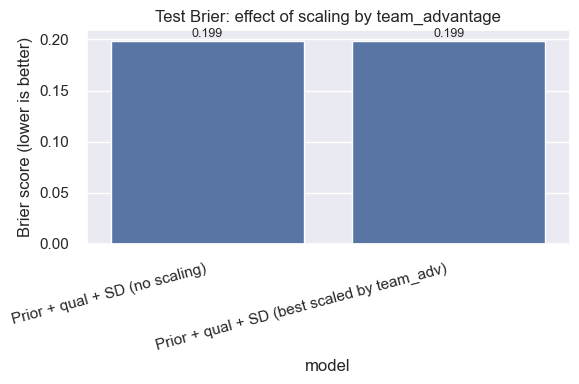

In [23]:
# Adjust prior+SD model predictions using team_advantage scalars and recompute test Brier

# We need per-row test predictions to apply scaling.
# Re-fit the per-combo models but this time keep predictions aligned to rows.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

MIN_N_LOGIT_PRIOR_SD_ADJ = 500

# Reuse the same prior_strength as in the previous cell
best_prior_strength_prior_sd_adj = best_prior_strength_prior_sd

# Rebuild train/test with player_prior_mean attached (same as previous cell)
key_cols_prior_sd = ['person_id', FEATURE_COMBO_COL]
prior_feat_prior_sd = priors_prior_sd[key_cols_prior_sd + ['player_prior_mean']]

train_prior_sd_rows = train_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')
test_prior_sd_rows = test_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')

# Containers for per-row predictions
all_test_probs_prior_sd = []
all_test_true_prior_sd = []
all_test_team_adv = []

for combo, combo_train in train_prior_sd_rows.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD_ADJ:
        continue

    combo_test = test_prior_sd_rows[test_prior_sd_rows[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    # Restrict to rows with valid shot_distance in both train and test
    combo_train = combo_train[
        combo_train['shot_distance'].notna() & (combo_train['shot_distance'] != 0)
    ].copy()
    combo_test = combo_test[
        combo_test['shot_distance'].notna() & (combo_test['shot_distance'] != 0)
    ].copy()

    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD_ADJ or combo_test.empty:
        continue

    # Compute average success rate for this combo on the (filtered) training data
    combo_mean = combo_train[TARGET_COL].mean()
    combo_train['combo_avg_success'] = combo_mean
    combo_test['combo_avg_success'] = combo_mean

    # Ensure qualifiers exists and is string-typed; fill missing player priors with combo_mean
    for df_ in (combo_train, combo_test):
        if 'qualifiers' not in df_.columns:
            df_['qualifiers'] = ''
        df_['qualifiers'] = df_['qualifiers'].fillna('').astype(str)
        df_['player_prior_mean'] = df_['player_prior_mean'].fillna(combo_mean)

    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train['qualifiers'])
    except ValueError:
        continue
    Xq_test = vect.transform(combo_test['qualifiers'])

    Xnum_train = combo_train[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values
    Xnum_test = combo_test[['combo_avg_success', 'player_prior_mean', 'shot_distance']].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values
    y_test = combo_test[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_prob_test_combo = clf.predict_proba(X_test)[:, 1]

    all_test_probs_prior_sd.append(y_prob_test_combo)
    all_test_true_prior_sd.append(y_test)
    # Capture team_advantage for scaling (can be nullable boolean)
    all_test_team_adv.append(combo_test['team_advantage'].values)

# Concatenate across combos
if all_test_probs_prior_sd:
    y_prob_test_all = np.concatenate(all_test_probs_prior_sd)
    y_true_test_all = np.concatenate(all_test_true_prior_sd)
    team_adv_all = np.concatenate(all_test_team_adv)

    # Original Brier for this model (sanity check)
    brier_prior_sd = np.mean((y_prob_test_all - y_true_test_all) ** 2)
    print(f"Original Brier (prior + qualifiers + shot_distance model): {brier_prior_sd:.6f}")

    # Grid search over scaling factors for team_advantage using test Brier as loss
    team_true_scales = np.linspace(1.00, 1.05, 11)   # e.g., 1.00, 1.005, ..., 1.05
    team_false_scales = np.linspace(0.95, 1.00, 11)  # e.g., 0.95, 0.955, ..., 1.00

    team_adv_series = pd.Series(team_adv_all)
    is_true = team_adv_series.eq(True).fillna(False).to_numpy(dtype=bool)
    is_false = team_adv_series.eq(False).fillna(False).to_numpy(dtype=bool)

    best_brier = brier_prior_sd
    best_true_scale = 1.0
    best_false_scale = 1.0

    for s_true in team_true_scales:
        for s_false in team_false_scales:
            scale = np.ones_like(y_prob_test_all, dtype=float)
            scale[is_true] = s_true
            scale[is_false] = s_false

            y_prob_scaled = y_prob_test_all * scale
            y_prob_scaled = np.clip(y_prob_scaled, 0.0, 1.0)

            brier_scaled = np.mean((y_prob_scaled - y_true_test_all) ** 2)
            if brier_scaled < best_brier:
                best_brier = brier_scaled
                best_true_scale = s_true
                best_false_scale = s_false

    print(f"Best scaling factors (team_adv=True, team_adv=False): {best_true_scale:.3f}, {best_false_scale:.3f}")
    print(f"Best scaled Brier: {best_brier:.6f}")

    # Bar chart comparing original vs best-scaled Brier
    comparison_scaled_df = pd.DataFrame({
        'model': [
            'Prior + qual + SD (no scaling)',
            'Prior + qual + SD (best scaled by team_adv)',
        ],
        'brier_score': [
            brier_prior_sd,
            best_brier,
        ],
    })

    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=comparison_scaled_df, x='model', y='brier_score')
    plt.ylabel('Brier score (lower is better)')
    plt.title('Test Brier: effect of scaling by team_advantage')
    plt.xticks(rotation=15, ha='right')

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.001,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
else:
    print('No combos produced test predictions for prior + qualifiers + shot_distance model.')



## Final comparison: SQ API vs trader.shotquality.com NCAAM model

Here we compare the **original SQ API test Brier score** to the **trader.shotquality.com NCAAM model** (player priors + qualifiers + shot distance, with team_advantage-based scaling) using a simple bar chart.


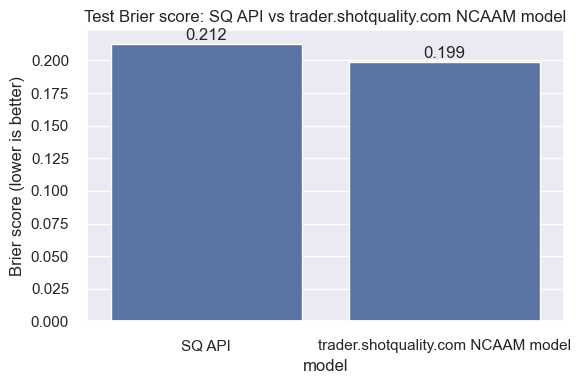

In [26]:
# Bar chart: SQ API vs trader.shotquality.com NCAAM model (test Brier)

# We assume:
# - brier_score: test Brier score from SQ API predictions (shots_df, predicted_shot_proba vs made)
# - best_brier: best scaled Brier from the trader.shotquality.com NCAAM model

comparison_final_df = pd.DataFrame({
    "model": ["SQ API", "trader.shotquality.com NCAAM model"],
    "brier_score": [brier_score, best_brier],
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=comparison_final_df, x="model", y="brier_score")
plt.ylabel("Brier score (lower is better)")
plt.title("Test Brier score: SQ API vs trader.shotquality.com NCAAM model")

# Annotate exact values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


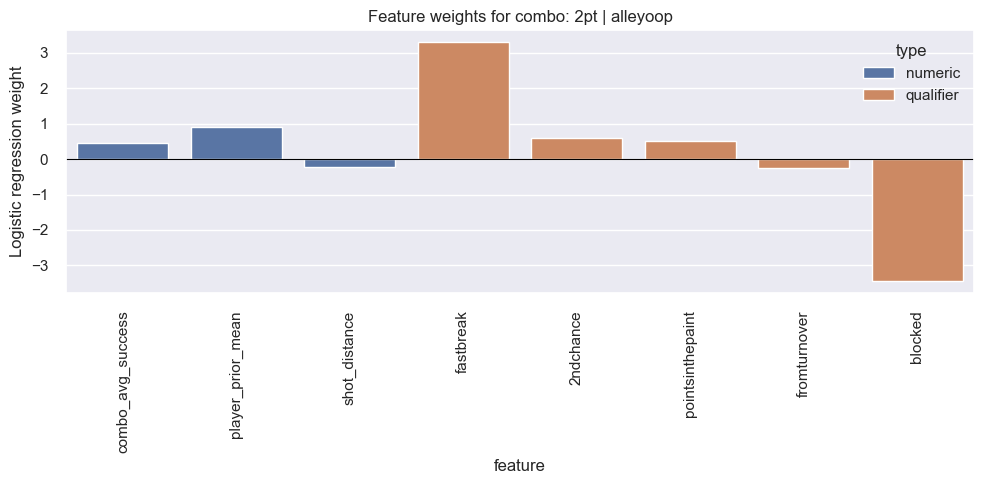

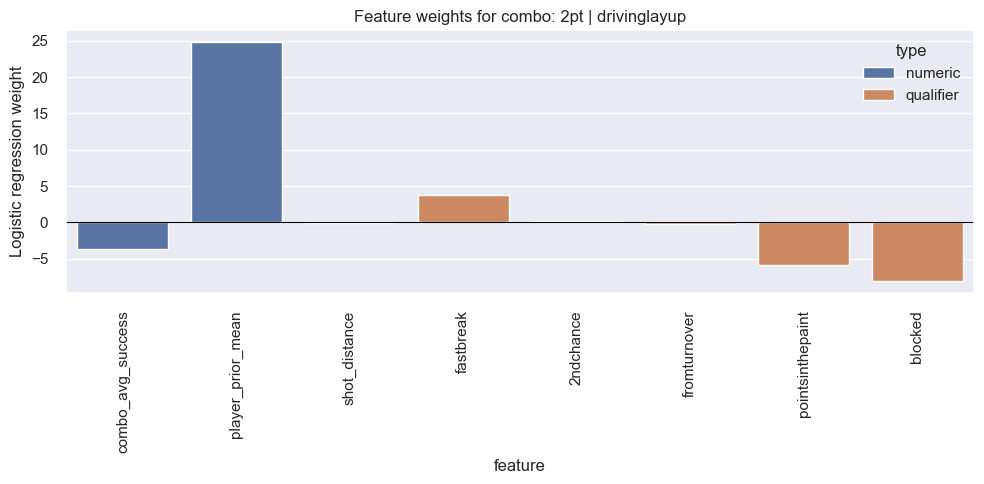

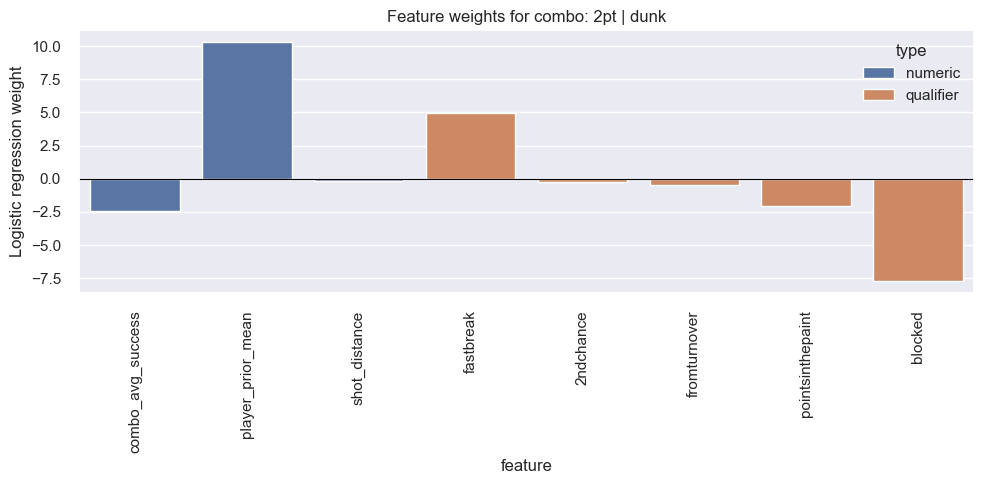

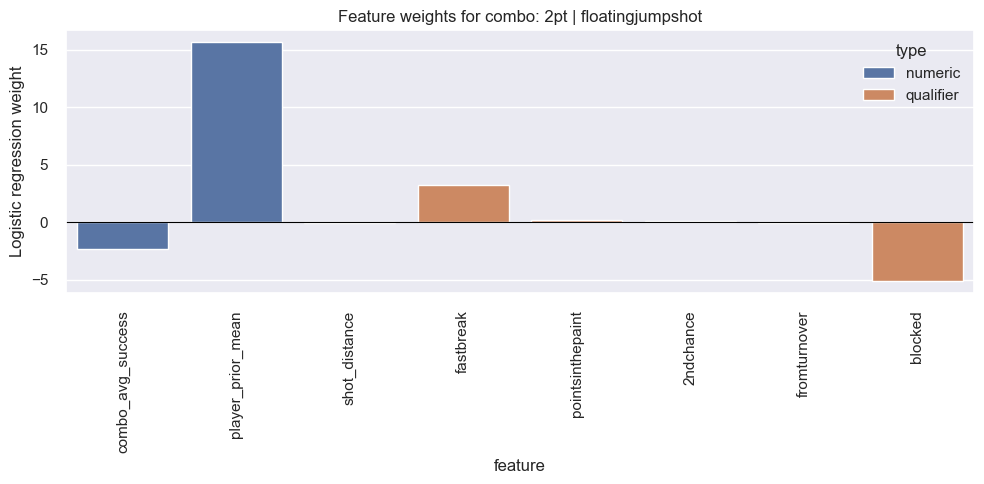

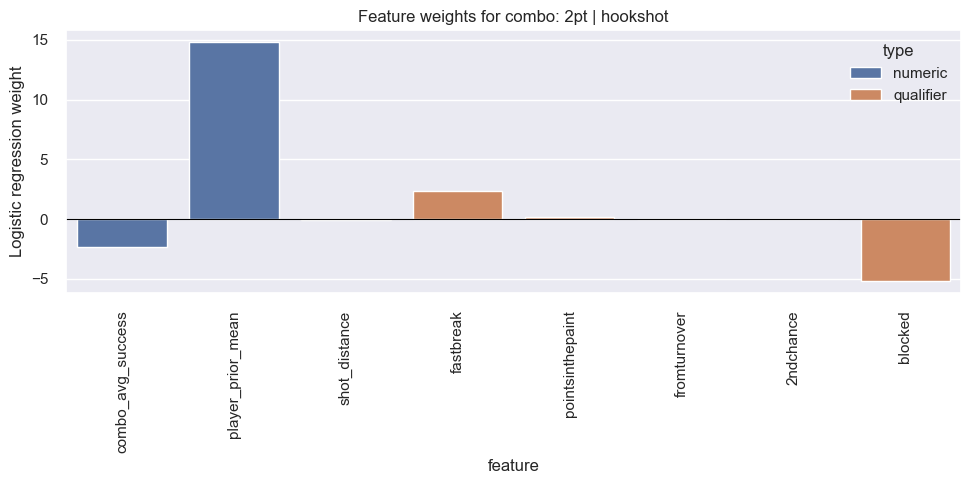

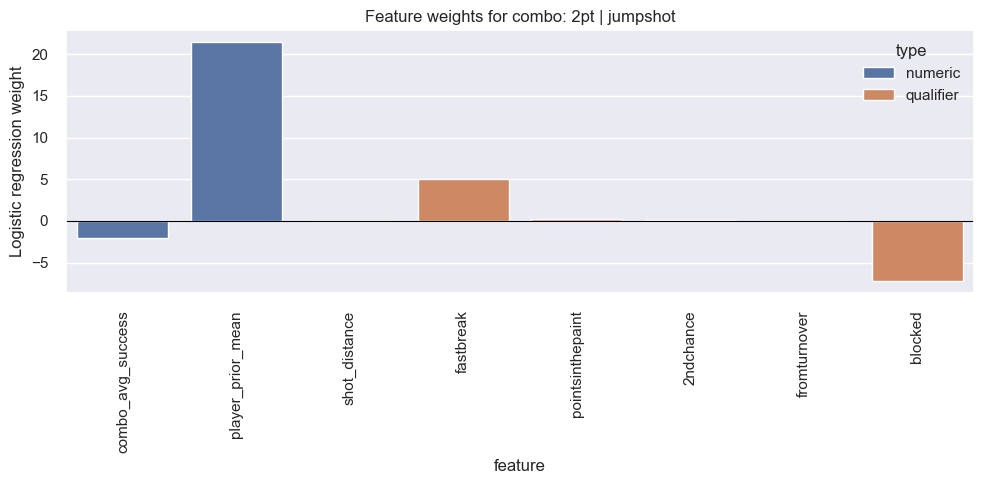

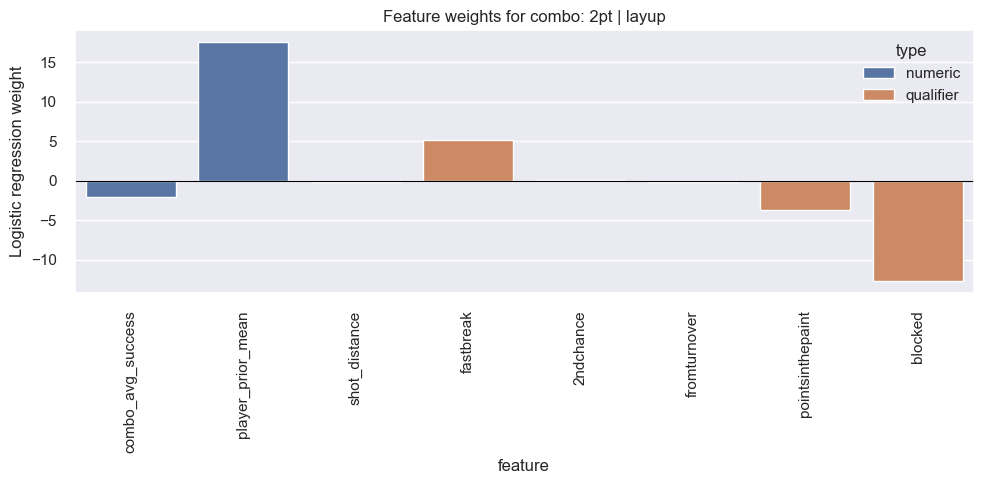

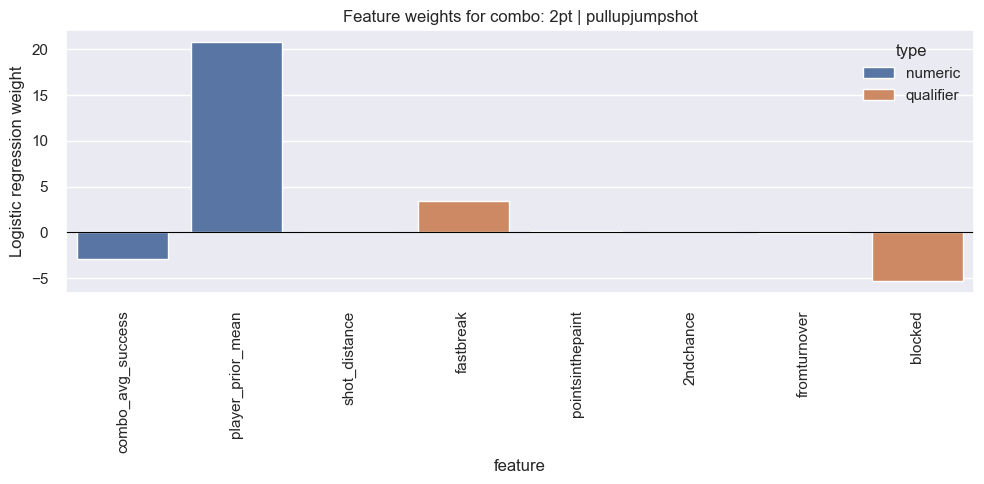

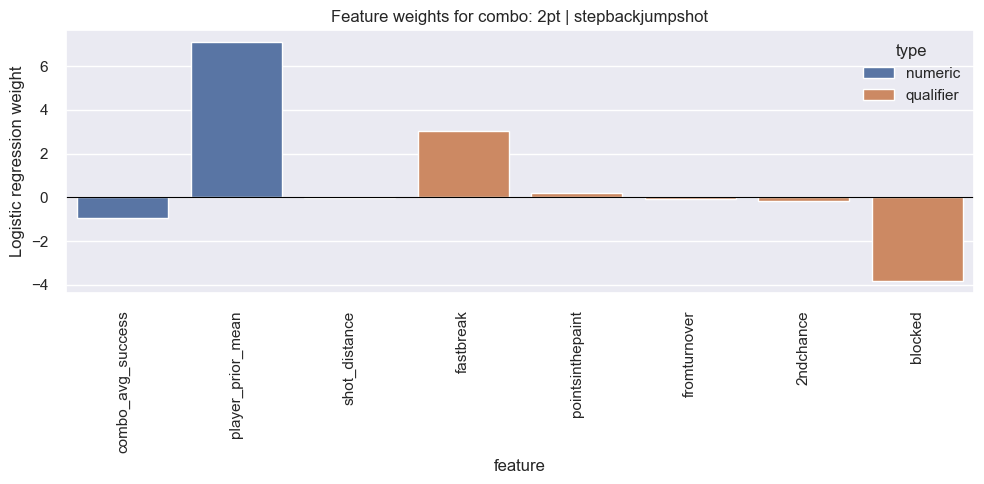

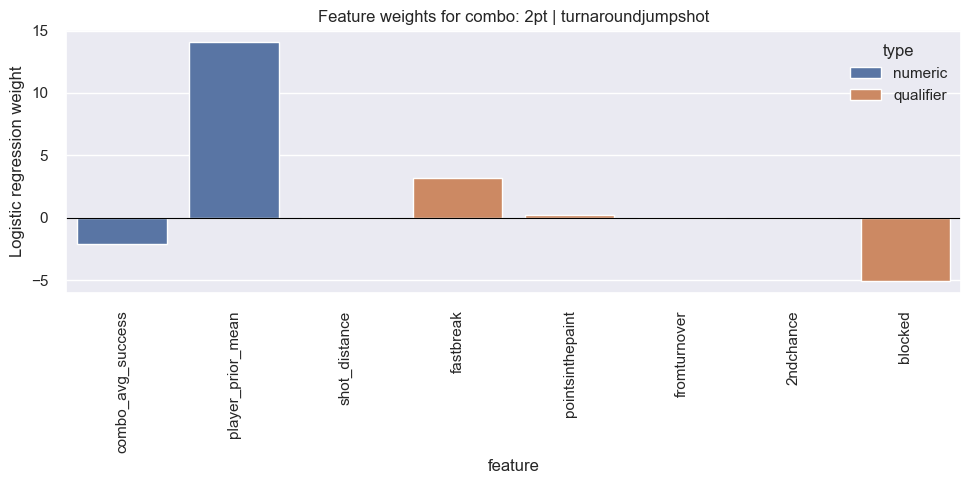

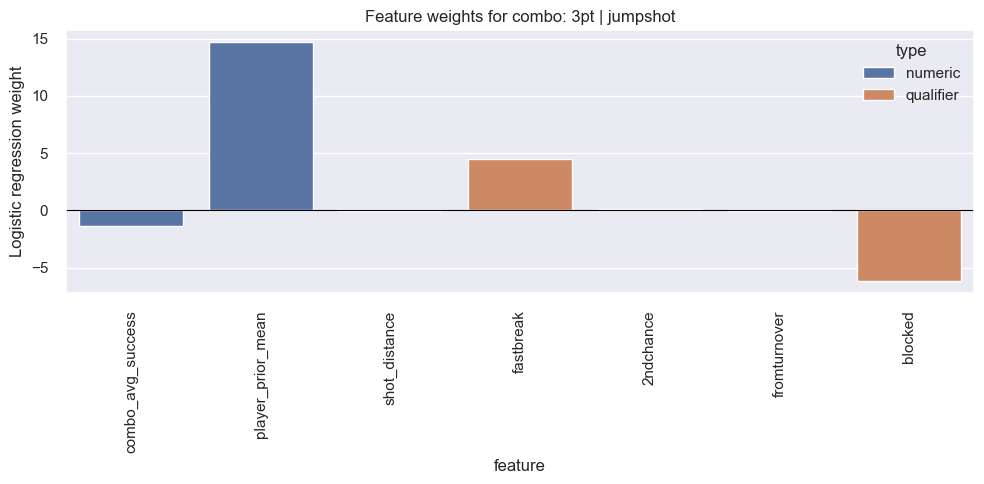

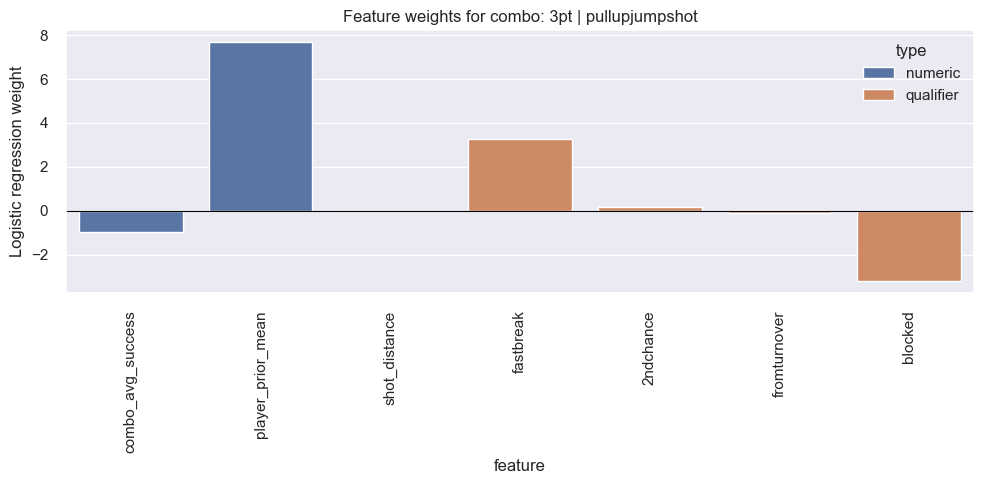

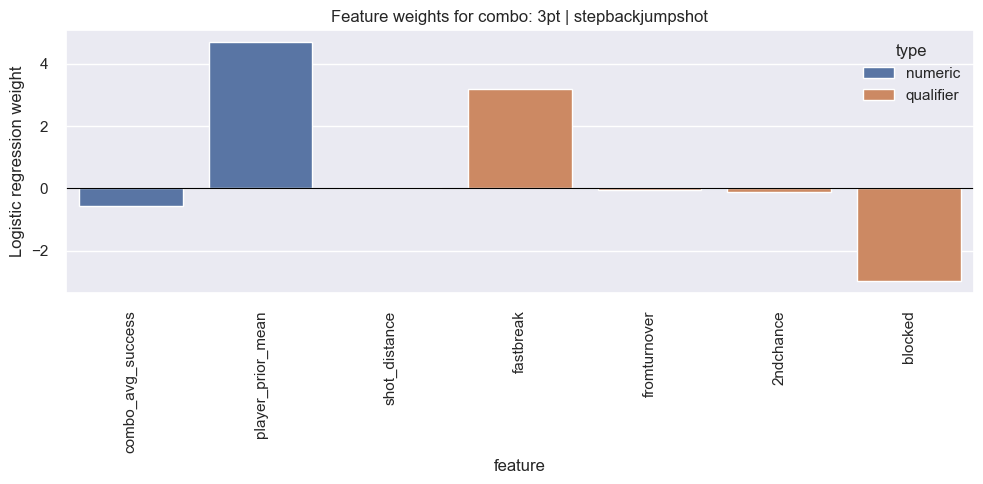

{
  "2pt | alleyoop": {
    "player_prior_mean": {
      "weight": 0.9074395012867852,
      "type": "numeric"
    },
    "combo_avg_success": {
      "weight": 0.44099385640685673,
      "type": "numeric"
    },
    "shot_distance": {
      "weight": -0.22579626158533192,
      "type": "numeric"
    },
    "fastbreak": {
      "weight": 3.2892251119978195,
      "type": "qualifier"
    },
    "2ndchance": {
      "weight": 0.5861877173069745,
      "type": "qualifier"
    },
    "pointsinthepaint": {
      "weight": 0.5011958548588397,
      "type": "qualifier"
    },
    "fromturnover": {
      "weight": -0.259906048458171,
      "type": "qualifier"
    },
    "blocked": {
      "weight": -3.4265674171155514,
      "type": "qualifier"
    }
  },
  "2pt | drivinglayup": {
    "player_prior_mean": {
      "weight": 24.77555914892722,
      "type": "numeric"
    },
    "shot_distance": {
      "weight": -0.14286164768760903,
      "type": "numeric"
    },
    "combo_avg_success": {
    

In [30]:
# Inspect and plot model weights for the trader.shotquality.com NCAAM model

# This cell re-fits the "final" logistic models (player prior + qualifiers + shot_distance)
# per action_type/sub_type combo and **plots** their learned coefficients.
# It also collects and outputs a tidy table of linear weights for each feature
# for each per-combo submodel.
# Note: this does *not* include the post-hoc team_advantage scaling factors;
# it shows the underlying logistic regression weights.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

MIN_N_LOGIT_PRIOR_SD_WEIGHTS = 500

# Rebuild player priors and train/test frames (mirrors the setup from the prior+SD model cells)
if 'combo_global_prior_sd' not in globals() or 'priors_prior_sd' not in globals():
    combo_global_prior_sd = (
        train_df.groupby(FEATURE_COMBO_COL)[TARGET_COL]
        .agg(global_makes='sum', global_attempts='count')
    )
    combo_global_prior_sd['global_rate'] = (
        combo_global_prior_sd['global_makes'] / combo_global_prior_sd['global_attempts']
    )

    if 'prior_grid_df' in globals() and not prior_grid_df.empty:
        best_prior_strength_prior_sd = float(
            prior_grid_df.sort_values('weighted_brier_test').iloc[0]['prior_strength']
        )
    else:
        best_prior_strength_prior_sd = 500.0

    priors_prior_sd = (
        train_df.groupby(['person_id', FEATURE_COMBO_COL])[TARGET_COL]
        .agg(player_makes='sum', player_attempts='count')
        .reset_index()
    )

    priors_prior_sd = priors_prior_sd.merge(
        combo_global_prior_sd[['global_rate']],
        left_on=FEATURE_COMBO_COL,
        right_index=True,
        how='left',
    )

    priors_prior_sd['alpha_prior'] = (
        priors_prior_sd['global_rate'] * best_prior_strength_prior_sd
    )
    priors_prior_sd['beta_prior'] = (
        (1.0 - priors_prior_sd['global_rate']) * best_prior_strength_prior_sd
    )

    priors_prior_sd['alpha_post'] = (
        priors_prior_sd['alpha_prior'] + priors_prior_sd['player_makes']
    )
    priors_prior_sd['beta_post'] = (
        priors_prior_sd['beta_prior'] +
        (priors_prior_sd['player_attempts'] - priors_prior_sd['player_makes'])
    )
    priors_prior_sd['player_prior_mean'] = (
        priors_prior_sd['alpha_post'] /
        (priors_prior_sd['alpha_post'] + priors_prior_sd['beta_post'])
    )

key_cols_prior_sd = ['person_id', FEATURE_COMBO_COL]
prior_feat_prior_sd = priors_prior_sd[key_cols_prior_sd + ['player_prior_mean']]

train_prior_sd_weights = train_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')
test_prior_sd_weights = test_df.merge(prior_feat_prior_sd, on=key_cols_prior_sd, how='left')

NUMERIC_FEATURE_NAMES = [
    'combo_avg_success',
    'player_prior_mean',
    'shot_distance',
]

max_text_features_to_show = 10  # top + bottom per combo

# Collect all coefficients across combos into a single DataFrame
all_coef_rows = []

for combo, combo_train in train_prior_sd_weights.groupby(FEATURE_COMBO_COL):
    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD_WEIGHTS:
        continue

    combo_test = test_prior_sd_weights[test_prior_sd_weights[FEATURE_COMBO_COL] == combo]
    if combo_test.empty:
        continue

    combo_train = combo_train[
        combo_train['shot_distance'].notna() & (combo_train['shot_distance'] != 0)
    ].copy()
    combo_test = combo_test[
        combo_test['shot_distance'].notna() & (combo_test['shot_distance'] != 0)
    ].copy()

    if len(combo_train) < MIN_N_LOGIT_PRIOR_SD_WEIGHTS or combo_test.empty:
        continue

    combo_mean = combo_train[TARGET_COL].mean()
    combo_train['combo_avg_success'] = combo_mean
    combo_test['combo_avg_success'] = combo_mean

    for df_ in (combo_train, combo_test):
        if 'qualifiers' not in df_.columns:
            df_['qualifiers'] = ''
        df_['qualifiers'] = df_['qualifiers'].fillna('').astype(str)
        df_['player_prior_mean'] = df_['player_prior_mean'].fillna(combo_mean)

    vect = CountVectorizer(binary=True, min_df=5)
    try:
        Xq_train = vect.fit_transform(combo_train['qualifiers'])
    except ValueError:
        continue
    Xq_test = vect.transform(combo_test['qualifiers'])

    Xnum_train = combo_train[NUMERIC_FEATURE_NAMES].values
    Xnum_test = combo_test[NUMERIC_FEATURE_NAMES].values

    X_train = hstack([Xnum_train, Xq_train])
    X_test = hstack([Xnum_test, Xq_test])

    y_train = combo_train[TARGET_COL].astype(int).values

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train, y_train)

    coef = clf.coef_[0]

    # Split numeric vs text coefficients
    numeric_coefs = dict(zip(NUMERIC_FEATURE_NAMES, coef[: len(NUMERIC_FEATURE_NAMES)]))
    feature_names_text = vect.get_feature_names_out()
    text_coefs = coef[len(NUMERIC_FEATURE_NAMES):]

    # Build a tidy DataFrame of coefficients
    coef_numeric_df = pd.DataFrame({
        'feature': list(numeric_coefs.keys()),
        'weight': list(numeric_coefs.values()),
        'type': 'numeric',
    })

    if len(feature_names_text) > 0:
        text_series = pd.Series(text_coefs, index=feature_names_text)
        top_pos = text_series.sort_values(ascending=False).head(max_text_features_to_show)
        top_neg = text_series.sort_values(ascending=True).head(max_text_features_to_show)
        text_subset = pd.concat([top_pos, top_neg])

        coef_text_df = pd.DataFrame({
            'feature': text_subset.index,
            'weight': text_subset.values,
            'type': 'qualifier',
        })

        coef_plot_df = pd.concat([coef_numeric_df, coef_text_df], ignore_index=True)
    else:
        coef_plot_df = coef_numeric_df

    # Attach combo identifier and accumulate for global table
    coef_plot_df = coef_plot_df.assign(combo=combo)
    all_coef_rows.append(coef_plot_df)

    # Plot bar chart of weights for this combo
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=coef_plot_df,
        x='feature',
        y='weight',
        hue='type',
        dodge=False,
    )
    plt.xticks(rotation=90)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"Feature weights for combo: {combo}")
    plt.ylabel("Logistic regression weight")
    plt.tight_layout()
    plt.show()

# Build and output a nested JSON object of linear weights across all per-combo models
import json

if all_coef_rows:
    all_coefs_df = pd.concat(all_coef_rows, ignore_index=True)
    # Sort for a stable, readable structure
    all_coefs_df = all_coefs_df.sort_values(['combo', 'type', 'weight'], ascending=[True, True, False])

    # Nested structure: { combo: { feature: {"weight": ..., "type": ...}, ... }, ... }
    all_coefs_json = {}
    for _, row in all_coefs_df.iterrows():
        combo_key = row['combo']
        feature_key = row['feature']
        if combo_key not in all_coefs_json:
            all_coefs_json[combo_key] = {}
        all_coefs_json[combo_key][feature_key] = {
            'weight': float(row['weight']),
            'type': row['type'],
        }

    # Pretty-print JSON so it can be copied/saved as needed
    print(json.dumps(all_coefs_json, indent=2))
else:
    print("No combos met the minimum sample size for weight extraction.")
